In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from astropy.cosmology import LambdaCDM
from matplotlib.lines import Line2D
from scipy.stats import chi2
import emcee
import corner
from pathlib import Path

In [2]:
# Load three ZTF data tables
snia = pd.read_csv("ztf_full_data.csv")
globalhost = pd.read_csv("globalhost_data.csv")
localhost = pd.read_csv("localhost_data.csv")

print("SN Ia table:", snia.shape)
print("Global-host table:", globalhost.shape)
print("Local-host table:", localhost.shape)

print("\nSN Ia columns:")
print(snia.columns.tolist())

print("\nGlobal-host columns:")
print(globalhost.columns.tolist())

print("\nLocal-host columns:")
print(localhost.columns.tolist())


def find_shared_key(left, right, candidates):
    for key in candidates:
        if key in left.columns and key in right.columns:
            return key

    shared = [column for column in left.columns if column in right.columns]

    if len(shared) == 1:
        return shared[0]

    raise KeyError(
        "Could not determine a unique merge key. "
        f"Shared columns are: {shared}"
    )


def find_column(data, candidates, description):
    for column in candidates:
        if column in data.columns:
            return column

    raise KeyError(
        f"Could not find {description}. Tried: {candidates}"
    )


# Identify merge keys
merge_candidates = ["ztfname", "ztf_name", "ZTFNAME", "name", "iau_name",]

global_key = find_shared_key(snia, globalhost, merge_candidates)

local_key = find_shared_key(snia, localhost, merge_candidates)

print(f"\nGlobal-host merge key: {global_key}")
print(f"Local-host merge key: {local_key}")


# Rename the generic host-property columns BEFORE merging
globalhost = globalhost.rename(columns={
    "mass": "globalmass",
    "mass_err": "globalmass_err",
    "restframe_gz": "globalrestframe_gz",
    "restframe_gz_err": "globalrestframe_gz_err",
})

localhost = localhost.rename(columns={
    "mass": "localmass",
    "mass_err": "localmass_err",
    "restframe_gz": "localrestframe_gz",
    "restframe_gz_err": "localrestframe_gz_err",
})


# If the local host table uses a differently named identifier, rename it to match the SN/global-host identifier
if local_key != global_key:
    localhost = localhost.rename(columns={local_key: global_key})


# Merge the three tables
metadata = snia.merge(
    globalhost,
    on=global_key,
    how="left"
)
metadata = metadata.merge(
    localhost,
    on=global_key,
    how="left"
)
print("\nMerged table:", metadata.shape)

# Identify columns actually used by the analysis
redshift_column = find_column(
    metadata,
    [
        "redshift",
        "z",
        "zhel",
    ],
    "ZTF redshift"
)

global_mass_column = find_column(
    metadata,
    [
        "globalmass",
        "global_mass",
        "logmass_global",
        "mass_global",
    ],
    "global host stellar mass"
)

local_mass_column = find_column(
    metadata,
    [
        "localmass",
        "local_mass",
        "logmass_local",
        "mass_local",
    ],
    "local host stellar mass"
)

global_color_column = find_column(
    metadata,
    [
        "globalrestframe_gz",
        "global_restframe_gz",
        "global_gz",
    ],
    "global host rest-frame g-z color"
)

local_color_column = find_column(
    metadata,
    [
        "localrestframe_gz",
        "local_restframe_gz",
        "local_gz",
    ],
    "local host rest-frame g-z color"
)


# Give merged quantities the common names
metadata["zHD"] = metadata[redshift_column]
metadata["HOST_LOGMASS"] = metadata[global_mass_column]
metadata["LOCAL_LOGMASS"] = metadata[local_mass_column]
metadata["HOST_COLOR"] = metadata[global_color_column]
metadata["LOCAL_COLOR"] = metadata[local_color_column]

print("\nColumns selected for the analysis:")
print(f"redshift          -> {redshift_column}")
print(f"global host mass  -> {global_mass_column}")
print(f"local host mass   -> {local_mass_column}")
print(f"global g-z        -> {global_color_column}")
print(f"local g-z         -> {local_color_column}")


# Quality cuts
metadata = metadata[metadata["lccoverage_flag"] == 1].copy()
metadata = metadata[metadata["fitquality_flag"] == 1].copy()
metadata = metadata[metadata["fitprob"] >= 1e-7].copy()
#metadata = metadata[metadata[redshift_column] <= 0.06].copy()
metadata = metadata[~metadata["sn_type"].fillna("").str.contains("pec", case=False)].copy()
metadata = metadata[(metadata["x0"] > 0)& (metadata["zHD"] > 0)].copy()


# Convert SALT x0 to mB and propagate the SALT covariance matrix
metadata["mB"] = -2.5 * np.log10(metadata["x0"]) + 10.5

dmB_dx0 = -2.5 / (np.log(10.0) * metadata["x0"])
metadata["mB_err"] = np.abs(dmB_dx0) * metadata["x0_err"]
metadata["COV_mB_x1"] = dmB_dx0 * metadata["cov_x0_x1"]
metadata["COV_mB_c"] = dmB_dx0 * metadata["cov_x0_c"]
metadata["COV_x1_c"] = metadata["cov_x1_c"]


# Fixed cosmology for the low-redshift ZTF analysis
H_0 = 70.0
Omega_M_fixed = 0.3
Omega_Lambda_fixed = 0.7

reference_cosmology = LambdaCDM(
    H0=H_0,
    Om0=Omega_M_fixed,
    Ode0=Omega_Lambda_fixed
)

metadata["MUMODEL"] = reference_cosmology.distmod(metadata["zHD"].clip(lower=1e-6)).value


# Redshift uncertainty
c_kms = 299792.458
vpec_sigma_kms = 250.0

if "redshift_err" in metadata.columns:
    z_measurement_err = metadata["redshift_err"]
else:
    z_measurement_err = np.zeros(len(metadata))

z_total_err = np.sqrt(z_measurement_err**2 + (vpec_sigma_kms / c_kms)**2)

metadata["MUERR_VPEC"] = 5.0 / np.log(10.0) * z_total_err / metadata["zHD"]

metadata["LENSDMUERR"] = 0.055 * metadata["zHD"]

metadata = metadata.replace([np.inf, -np.inf], np.nan)


# Summary.
print(
    f"\nZTF sample after quality cuts: "
    f"N = {len(metadata)}"
)

print(
    f"Redshift range: "
    f"{metadata['zHD'].min():.5f} "
    f"< z < "
    f"{metadata['zHD'].max():.5f}"
)

print(
    f"Objects with global mass: "
    f"{metadata['HOST_LOGMASS'].notna().sum()}"
)

print(
    f"Objects with local mass: "
    f"{metadata['LOCAL_LOGMASS'].notna().sum()}"
)

print(
    f"Objects with global g-z: "
    f"{metadata['HOST_COLOR'].notna().sum()}"
)

print(
    f"Objects with local g-z: "
    f"{metadata['LOCAL_COLOR'].notna().sum()}"
)

SN Ia table: (3628, 41)
Global-host table: (3628, 8)
Local-host table: (3628, 5)

SN Ia columns:
['ztfname', 'ra_host', 'dec_host', 'mass_x', 'mass_err_x', 'restframe_gz_x', 'restframe_gz_err_x', 'd_dlr', 'mass_y', 'mass_err_y', 'restframe_gz_y', 'restframe_gz_err_y', 'redshift', 'redshift_err', 'source', 't0', 'x0', 'x1', 'c', 't0_err', 'x0_err', 'x1_err', 'c_err', 'cov_t0_x0', 'cov_t0_x1', 'cov_t0_c', 'cov_x0_x1', 'cov_x0_c', 'cov_x1_c', 'mwebv', 'mwr_v', 'mwebv_err', 'fitprob', 'ra', 'dec', 'sn_type', 'sub_type', 'lccoverage_flag', 'fitquality_flag', 'iau_name', 'frac_fitted']

Global-host columns:
['ztfname', 'ra_host', 'dec_host', 'mass', 'mass_err', 'restframe_gz', 'restframe_gz_err', 'd_dlr']

Local-host columns:
['ztfname', 'mass', 'mass_err', 'restframe_gz', 'restframe_gz_err']

Global-host merge key: ztfname
Local-host merge key: ztfname

Merged table: (3628, 52)

Columns selected for the analysis:
redshift          -> redshift
global host mass  -> globalmass
local host mass 

## Define sample selections

- **`mass_cut`**: Median values used to split the mass sample.
- **`low_z` / `high_z`**: Low- and high-redshift supernovae.
- **`low_mass` / `high_mass`**: Host galaxy stellar mass categories.
- **`blue` / `red`**: Host galaxy color categories.

In [3]:
mass_cut = 10.0
color_cut = 1.0

low_z = metadata["zHD"] < 0.1
high_z = metadata["zHD"] >= 0.1

low_mass = metadata["HOST_LOGMASS"] < mass_cut
high_mass = metadata["HOST_LOGMASS"] >= mass_cut

blue = metadata["HOST_COLOR"] < color_cut
red = metadata["HOST_COLOR"] >= color_cut

In [5]:
all_samples = {
    "all": metadata,
    }

sample = all_samples["all"]

M_B_ref = -19.3
alpha_ref = 0.14
beta_ref = 3.0
gamma_ref = 0.0

HM_ref = (sample["HOST_LOGMASS"] >= mass_cut).astype(float)

sample["MU"] = (
    sample["mB"]
    - M_B_ref
    + alpha_ref * sample["x1"]
    - beta_ref * sample["c"]
    + gamma_ref * HM_ref
)

sample["MUERR"] = np.sqrt(
    sample["mB_err"]**2
    + (alpha_ref * sample["x1_err"])**2
    + (beta_ref * sample["c_err"])**2
    + 2.0 * alpha_ref * sample["COV_mB_x1"]
    - 2.0 * beta_ref * sample["COV_mB_c"]
    - 2.0 * alpha_ref * beta_ref * sample["COV_x1_c"]
    + sample["MUERR_VPEC"]**2
    + sample["LENSDMUERR"]**2
)

all_samples["all"] = sample

z_samples = {
    "Low redshift": metadata[low_z],
    "High redshift": metadata[high_z],
    }

z_m_samples = {
    "Low redshift, low-mass hosts": metadata[low_z & low_mass],
    "Low redshift, high-mass hosts": metadata[low_z & high_mass],
    "High redshift, low-mass hosts": metadata[high_z & low_mass],
    "High redshift, high-mass hosts": metadata[high_z & high_mass],
    }

z_c_samples = {
    "Low redshift, redder hosts": metadata[low_z & red],
    "Low redshift, bluer hosts": metadata[low_z & blue],
    "High redshift, redder hosts": metadata[high_z & red],
    "High redshift, bluer hosts": metadata[high_z & blue],
    }

## Hubble diagram for the full sample

Plots distance modulus (**`MU`**) versus redshift (**`zHD`**) for every supernova.

- **`MU`** is the measured distance modulus.
- **`MUERR`** provides the uncertainty on each measurement.
- **`MUMODEL`** is the predicted distance modulus from the reference cosmological model.

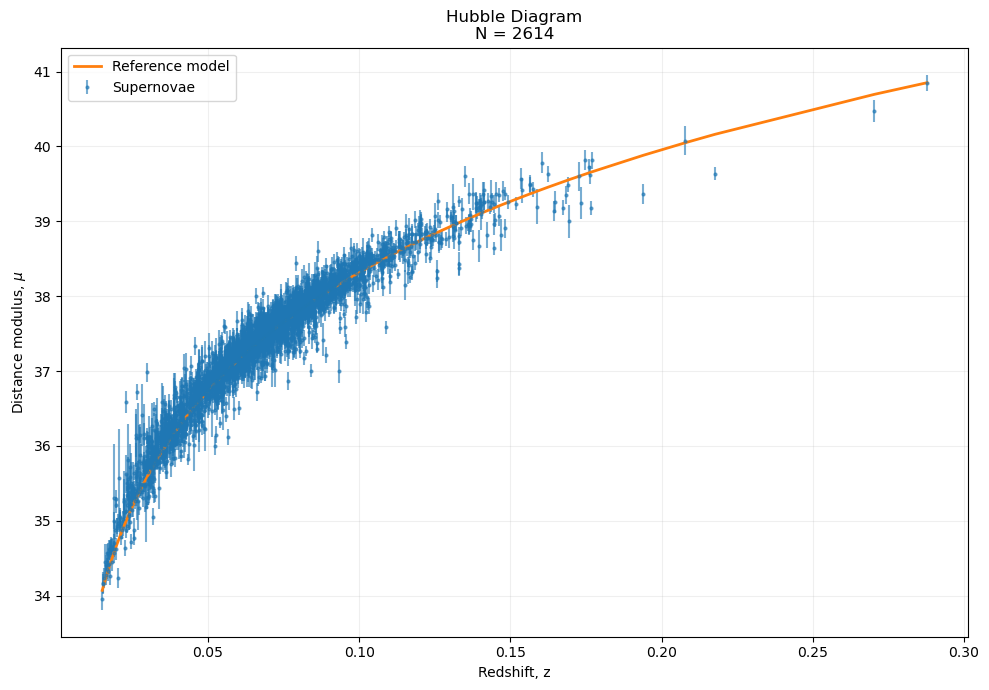

In [6]:
plt.figure(figsize=(10, 7))

M_B_ref = -19.3
alpha_ref = 0.14
beta_ref = 3.0
gamma_ref = 0.0

sample = all_samples["all"]

plt.errorbar(
    sample["zHD"],
    sample["MU"],
    yerr=sample["MUERR"],
    fmt=".",
    markersize=4,
    alpha=0.6,
    capsize=0,
    label="Supernovae"
)

model = sample.sort_values("zHD")

plt.plot(
    model["zHD"],
    model["MUMODEL"],
    linewidth=2,
    label="Reference model"
)

plt.xlabel("Redshift, z")
plt.ylabel(r"Distance modulus, $\mu$")
plt.title(f"Hubble Diagram\nN = {len(sample)}")
plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

## Compare low- and high-redshift samples

Creates Hubble diagrams for the low- and high-redshift subsets to compare how the observations agree with the reference cosmology.

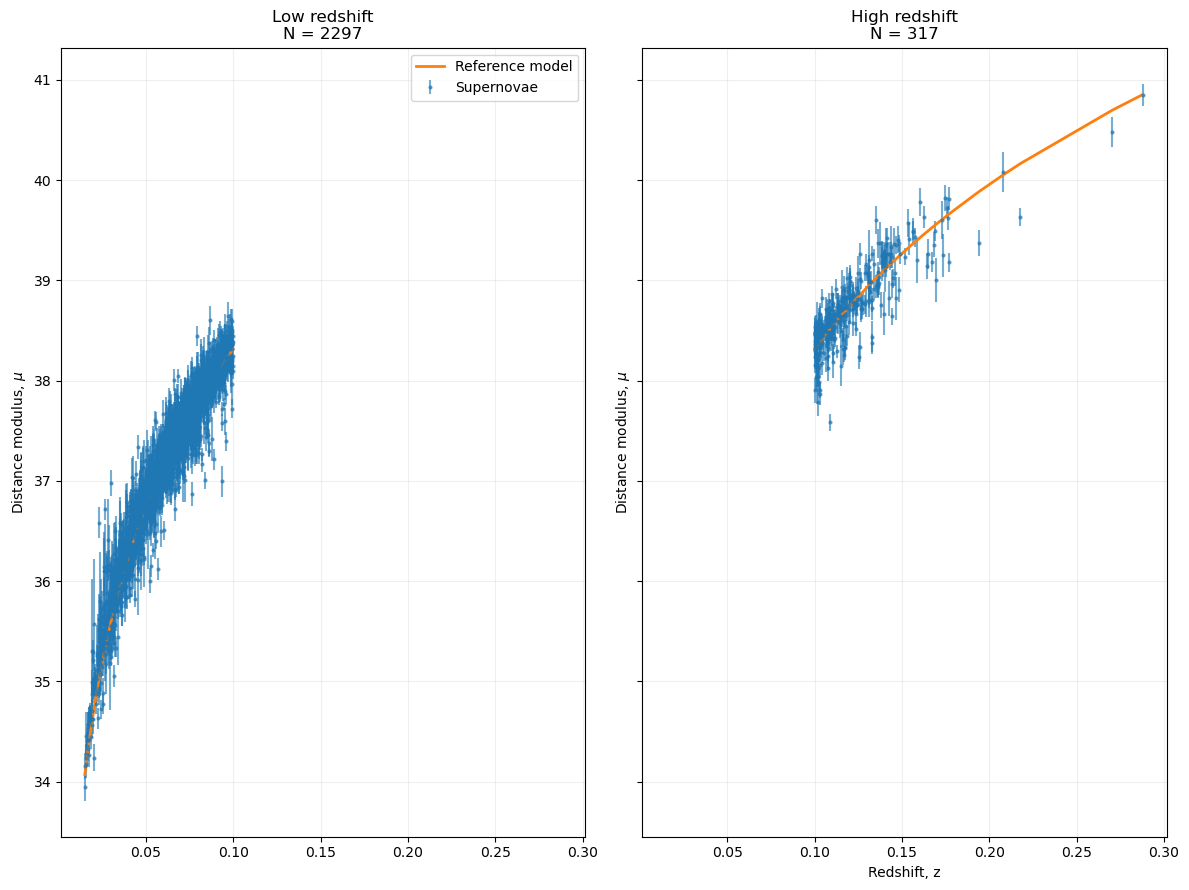

In [8]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 9),
    sharex=True,
    sharey=True
)

for ax, (title, sample) in zip(axes.flat, z_samples.items()):
    
    # Plot measured distance moduli.
    ax.errorbar(
        sample["zHD"],
        sample["MU"],
        yerr=sample["MUERR"],
        fmt=".",
        markersize=4,
        alpha=0.6,
        capsize=0,
        label="Supernovae"
    )

    # Plot the reference cosmological model.
    model = sample.sort_values("zHD")

    ax.plot(
        model["zHD"],
        model["MUMODEL"],
        linewidth=2,
        label="Reference model"
    )

    ax.set_title(f"{title}\nN = {len(sample)}")
    ax.set_ylabel(r"Distance modulus, $\mu$")
    ax.grid(alpha=0.2)


axes[1].set_xlabel("Redshift, z")
axes[0].legend()


plt.tight_layout()
plt.show()

## Compare host galaxy mass

Creates Hubble diagrams split by both redshift and host galaxy stellar mass, allowing any mass-dependent trends to be visually inspected.

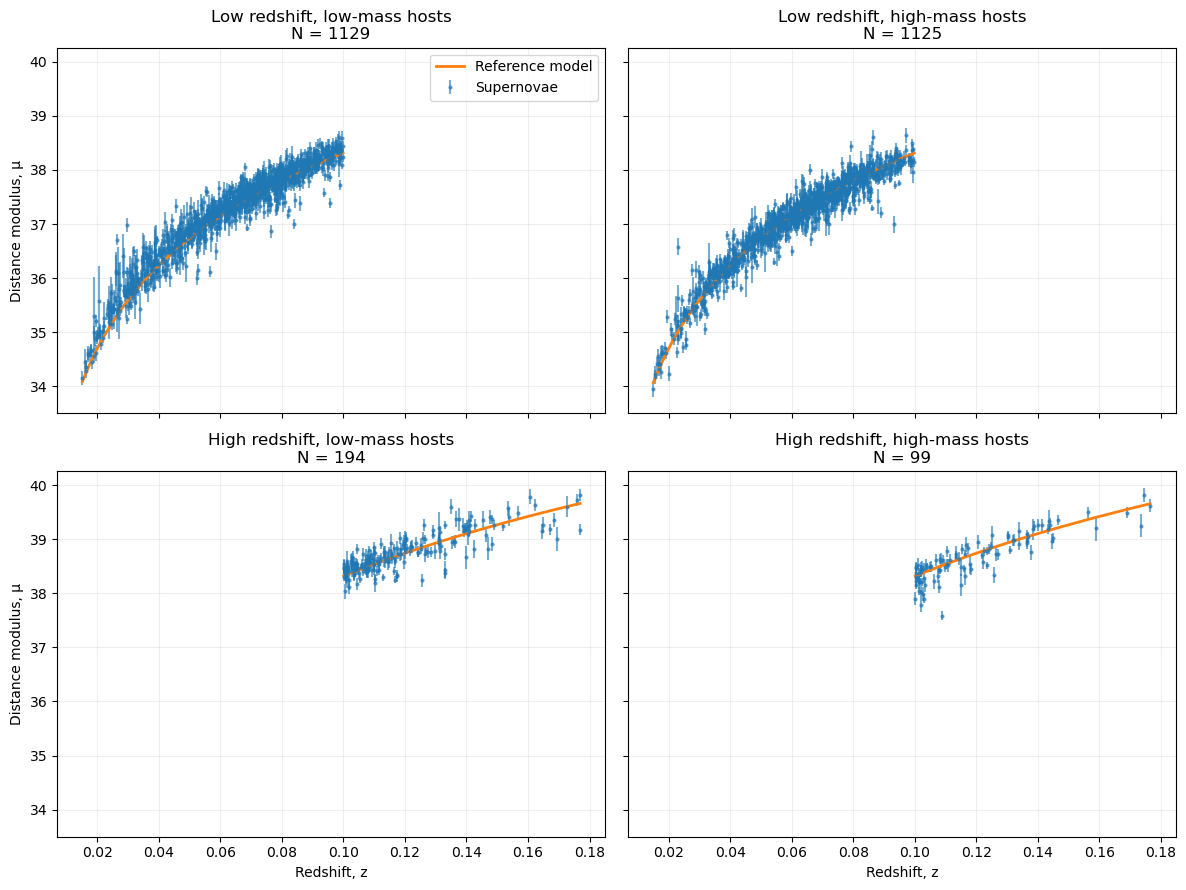

In [9]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9),
    sharex=True,
    sharey=True
)

for ax, (title, sample) in zip(axes.flat, z_m_samples.items()):

    # Plot measured distance moduli.
    ax.errorbar(
        sample["zHD"],
        sample["MU"],
        yerr=sample["MUERR"],
        fmt=".",
        markersize=4,
        alpha=0.6,
        capsize=0,
        label="Supernovae"
    )

    # Plot the reference cosmological model.
    model = sample.sort_values("zHD")

    ax.plot(
        model["zHD"],
        model["MUMODEL"],
        linewidth=2,
        label="Reference model"
    )

    ax.set_title(f"{title}\nN = {len(sample)}")
    ax.grid(alpha=0.2)

axes[0, 0].set_ylabel("Distance modulus, μ")
axes[1, 0].set_ylabel("Distance modulus, μ")

axes[1, 0].set_xlabel("Redshift, z")
axes[1, 1].set_xlabel("Redshift, z")

axes[0, 0].legend()

plt.tight_layout()
plt.show()

## Compare host galaxy color

Compares Hubble diagrams for blue and red host galaxy populations.

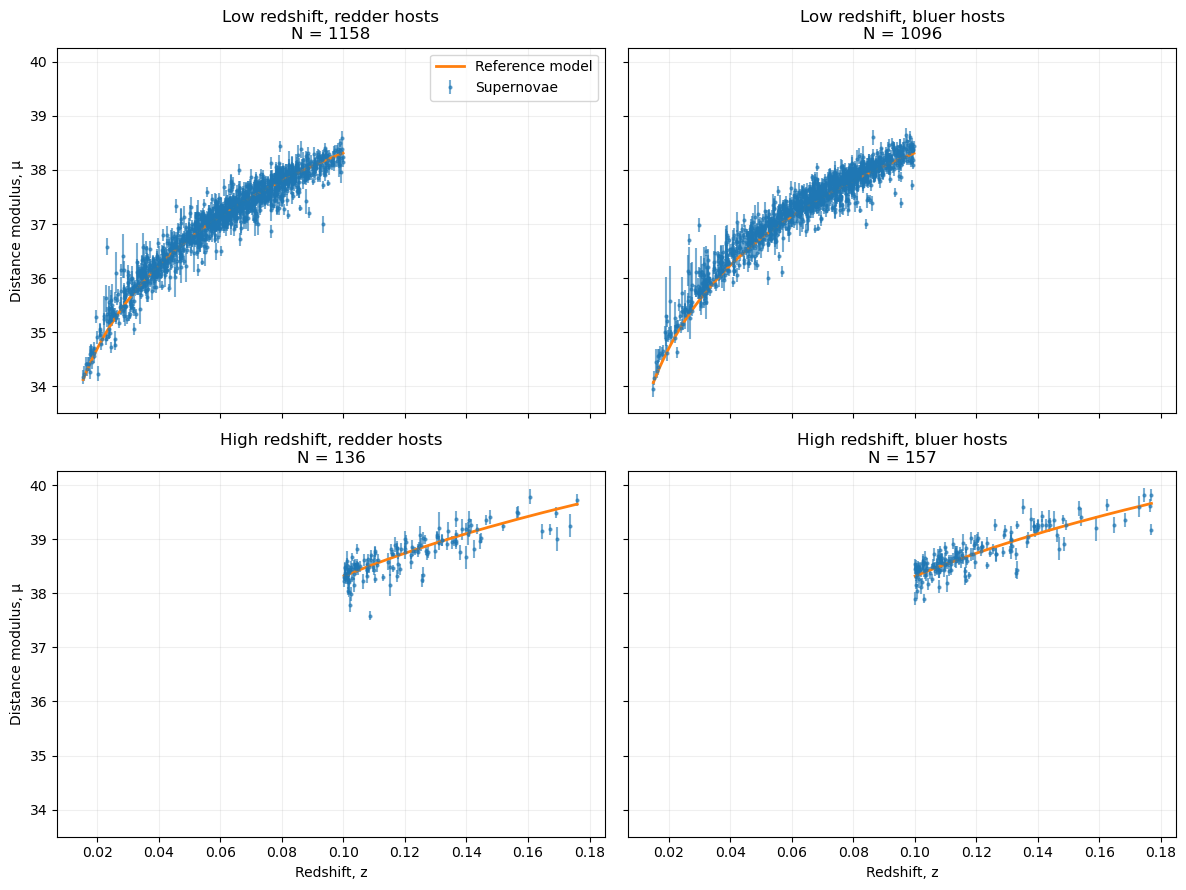

In [10]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9),
    sharex=True,
    sharey=True
)

for ax, (title, sample) in zip(axes.flat, z_c_samples.items()):

    # Plot measured distance moduli.
    ax.errorbar(
        sample["zHD"],
        sample["MU"],
        yerr=sample["MUERR"],
        fmt=".",
        markersize=4,
        alpha=0.6,
        capsize=0,
        label="Supernovae"
    )

    # Plot the reference cosmological model.
    model = sample.sort_values("zHD")

    ax.plot(
        model["zHD"],
        model["MUMODEL"],
        linewidth=2,
        label="Reference model"
    )

    ax.set_title(f"{title}\nN = {len(sample)}")
    ax.grid(alpha=0.2)

axes[0, 0].set_ylabel("Distance modulus, μ")
axes[1, 0].set_ylabel("Distance modulus, μ")

axes[1, 0].set_xlabel("Redshift, z")
axes[1, 1].set_xlabel("Redshift, z")

axes[0, 0].legend()

plt.tight_layout()
plt.show()

In [11]:
def weighted_mean_and_error(values, errors):
    weights = 1.0 / errors**2
    mean = np.average(values, weights=weights)
    error = np.sqrt(1.0 / weights.sum())
    return mean, error

# Cosmological Parameter Fitting

This section contains the MCMC analysis. The workflow is organized in execution order:

1. Define the likelihood, priors, and helper functions.
2. Build the non-clipped analysis samples.
3. Run all non-clipped 3D fits.
4. Use the non-clipped 3D fits to define the 2.5-sigma clipped samples.
5. Run the clipped fits.
6. Make the final Hubble diagrams.

### Covariance Matrix

The light-curve fitter simultaneously determines three light-curve parameters:

* $x_0$, which is converted into the apparent magnitude (m_B),
* $x_1$, the stretch parameter,
* $c$, the color parameter.

Because these parameters are fitted simultaneously, their uncertainties are generally correlated. These correlations are described by the covariance matrix

$$
\begin{pmatrix}
\sigma_{x_0}^2 &
\mathrm{Cov}(x_0,x_1) &
\mathrm{Cov}(x_0,c) \\
\mathrm{Cov}(x_1,x_0) &
\sigma_{x_1}^2 &
\mathrm{Cov}(x_1,c) \\
\mathrm{Cov}(c,x_0) &
\mathrm{Cov}(c,x_1) &
\sigma_c^2
\end{pmatrix}.
$$

The diagonal elements are the variances of the fitted parameters, while the off-diagonal elements are the covariances, which quantify how the uncertainties in two parameters are correlated.

The metadata file stores the off-diagonal covariance terms as the columns

* `COV_x1_x0`,
* `COV_c_x0`,
* `COV_x1_c`.

Since the cosmological analysis uses the apparent magnitude $m_B$ rather than the normalization parameter $x_0$, the covariance terms involving $x_0$ are transformed using

$$
m_B = -2.5\log_{10}(x_0) + \mathrm{constant},
$$

whose derivative is

$$
\frac{dm_B}{dx_0} = -\frac{2.5}{x_0\ln10}.
$$

Applying standard uncertainty propagation gives

$$
\mathrm{Cov}(m_B,x_1) = \frac{dm_B}{dx_0} \mathrm{Cov}(x_0,x_1),
$$

and

$$
\mathrm{Cov}(m_B,c) = \frac{dm_B}{dx_0} \mathrm{Cov}(x_0,c).
$$

These transformed covariance terms are then used when propagating the uncertainty in the reconstructed distance modulus,

$$
\mu_{\rm obs} = m_B - M_B + \alpha x_1 - \beta c + \gamma HM,
$$

ensuring that the likelihood correctly accounts for the correlated uncertainties in the light-curve parameters.


In [28]:
# FIXED
H_0 = 70.0
sigma_int = 0.10

def log_prior(theta):
    """
    Defines which parameter values the MCMC is allowed to explore.
    Returns:
        0.0      for an allowed parameter combination
        -np.inf  for a forbidden parameter combination
    Because the posterior is evaluated in logarithmic form, returning -np.inf makes the posterior probability exactly zero.
    """
    nparam = len(theta)
    
    if nparam == 3:
        M_B, alpha, beta = theta
        if (
            -20.5 < M_B < -18.0
            and 0.0 < alpha < 0.5
            and 0.0 < beta < 6.0
        ):
            return 0.0
        else:
            return -np.inf

    elif nparam == 4:
        M_B, alpha, beta, gamma = theta
        if (
            -20.5 < M_B < -18.0
            and 0.0 < alpha < 0.5
            and 0.0 < beta < 6.0
            and -0.5 < gamma < 0.5
        ):
            return 0.0
        else:
            return -np.inf
    else:
        raise ValueError("Unexpected size? len(theta) should be 3 or 4")    


def log_likelihood(theta, data):
    """
    Compares the measured distance moduli with the distance moduli predicted by the proposed cosmological parameters.
    Theta contains the proposed cosmological parameters.
    Data is a tuple containing:
        redshift
        observed distance modulus
        distance-modulus uncertainty
    """
    nparam = len(theta)

    if nparam == 3:
        M_B, alpha, beta = theta
        (
            redshift,
            mB,
            x1,
            c,
            host_logmass,
            mB_err,
            x1_err,
            c_err,
            cov_mB_x1,
            cov_mB_c,
            cov_x1_c,
            muerr_vpec,
            lensdmuerr
        ) = data
        mu_obs = mB - M_B + alpha*x1 - beta*c
        variance = mB_err**2 + alpha**2*x1_err**2 + beta**2*c_err**2 + 2.0*alpha*cov_mB_x1 - 2.0*beta*cov_mB_c - 2.0*alpha*beta*cov_x1_c + muerr_vpec**2 + lensdmuerr**2 + sigma_int**2

    elif nparam == 4:
        M_B, alpha, beta, gamma = theta
        (
            redshift,
            mB,
            x1,
            c,
            host_logmass,
            mB_err,
            x1_err,
            c_err,
            cov_mB_x1,
            cov_mB_c,
            cov_x1_c,
            muerr_vpec,
            lensdmuerr
        ) = data
        HM = (host_logmass >= mass_cut).astype(float)
        mu_obs = mB - M_B + alpha*x1 - beta*c + gamma*HM
        variance = mB_err**2 + alpha**2*x1_err**2 + beta**2*c_err**2 + 2.0*alpha*cov_mB_x1 - 2.0*beta*cov_mB_c - 2.0*alpha*beta*cov_x1_c + muerr_vpec**2 + lensdmuerr**2 + sigma_int**2
    else:
        raise ValueError("Unexpected size? len(theta) should be 5 or 6")    


    # Construct Astropy LambdaCDM cosmology using the current proposed values of H0, Omega_M, and Omega_Lambda.
    # H0: Present-day Hubble expansion rate in km/s/Mpc.
    # Om0: Present-day matter density parameter Omega_M.
    # Ode0: Present-day dark-energy density parameter Omega_Lambda.
    
    cosmology = LambdaCDM(
        H0=H_0,
        Om0=0.3,
        Ode0=0.7
    )
    
    with np.errstate(invalid="ignore"):
        mu_pred = cosmology.distmod(redshift).value
    
    if not np.all(np.isfinite(mu_pred)):
        return -np.inf
    
    residuals = mu_obs - mu_pred
    
    if np.any(~np.isfinite(variance)) or np.any(variance <= 0.0):
        return -np.inf
    
    loglike = -0.5 * np.sum(np.log(2.0 * np.pi * variance) + residuals**2 / variance)

    return loglike

def log_posterior(theta, data):
    logpr = log_prior(theta)
    if logpr == -np.inf:
        return logpr
    else:
        return logpr + log_likelihood(theta, data)

def make_data_tuple(sample, nparam):
    if nparam in (3, 4):
        return (
            sample["zHD"].to_numpy(),
            sample["mB"].to_numpy(),
            sample["x1"].to_numpy(),
            sample["c"].to_numpy(),
            sample["HOST_LOGMASS"].to_numpy(),
            sample["mB_err"].to_numpy(),
            sample["x1_err"].to_numpy(),
            sample["c_err"].to_numpy(),
            sample["COV_mB_x1"].to_numpy(),
            sample["COV_mB_c"].to_numpy(),
            sample["COV_x1_c"].to_numpy(),
            sample["MUERR_VPEC"].to_numpy(),
            sample["LENSDMUERR"].to_numpy()
        )

    else:
        raise ValueError("nparam should be 3 or 4")

def make_starting_positions(initial_guess, nwalkers, random_seed=None):
    rng = np.random.default_rng(random_seed)
    ndim = len(initial_guess)

    if ndim == 3:
        scales = np.array([0.02, 0.01, 0.10])
    
    elif ndim == 4:
        scales = np.array([0.02, 0.01, 0.10, 0.01])

    else:
        raise ValueError("initial_guess must contain 3 or 4 parameters")

    positions = initial_guess + scales * rng.normal(size=(nwalkers, ndim))

    for i in range(nwalkers):
        while not np.isfinite(log_prior(positions[i])):
            positions[i] = initial_guess + scales * rng.normal(size=ndim)

    return positions


def run_mcmc(data, initial_guess, nwalkers=32, nsteps=5000, burnin=1000, thin=1, random_seed=None):
    ndim = len(initial_guess)

    if nwalkers < 2 * ndim:
        raise ValueError("nwalkers must be at least twice ndim")

    if burnin >= nsteps:
        raise ValueError("burnin must be smaller than nsteps")

    starting_positions = make_starting_positions(
        initial_guess,
        nwalkers,
        random_seed=random_seed
    )

    sampler = emcee.EnsembleSampler(
        nwalkers,
        ndim,
        log_posterior,
        args=(data,),
        threads = 8
    )

    sampler.run_mcmc(
        starting_positions,
        nsteps,
        progress=True
    )

    samples = sampler.get_chain(
        discard=burnin,
        thin=thin,
        flat=True
    )

    return sampler, samples


def summarize_samples(name, samples, filename=None):
    if samples.shape[1] == 3:
        labels = ["M_B", "alpha", "beta"]
    elif samples.shape[1] == 4:
        labels = ["M_B", "alpha", "beta", "gamma"]
    else:
        raise ValueError("Samples must contain 5 or 6 columns")

    percentiles = np.percentile(samples, [16, 50, 84], axis=0)

    print(f"\n{name}")

    summary = {}
    summary_lines = [name]

    for i, label in enumerate(labels):
        median = percentiles[1, i]
        lower = median - percentiles[0, i]
        upper = percentiles[2, i] - median

        summary[label] = {
            "median": median,
            "minus": lower,
            "plus": upper
        }

        line = f"{label} = {median:.4f} -{lower:.4f} +{upper:.4f}"

        print(line)
        summary_lines.append(line)

    if filename is not None:
        filename = Path(filename)
        filename.parent.mkdir(parents=True, exist_ok=True)

        summary_text = "\n".join(summary_lines)

        with open(filename, "w") as f:
            f.write(summary_text)

    return summary

def get_corner_ranges(samples1, samples2):
    combined = np.vstack([samples1, samples2])
    ranges = []

    for i in range(combined.shape[1]):
        low = np.min(combined[:, i])
        high = np.max(combined[:, i])
        padding = 0.05 * (high - low)

        ranges.append((low - padding, high + padding))

    return ranges

def plot_overlaid_corner(samples_1, samples_2, label_1, label_2, title, color_1, color_2, filename=None):
    
    ndim = samples_1.shape[1]

    if samples_2.shape[1] != ndim:
        raise ValueError("Both sample arrays must have the same number of columns")

    #corner_ranges = get_corner_ranges(samples_1, samples_2)
    
    if ndim == 3:
        parameter_labels = [
            r"$M_B$",
            r"$\alpha$",
            r"$\beta$",
        ]
    
    elif ndim == 4:
        parameter_labels = [
            r"$M_B$",
            r"$\alpha$",
            r"$\beta$",
            r"$\gamma$"
        ]

    else:
        raise ValueError("Samples must contain 3 or 4 columns")
    
    figure = corner.corner(
        samples_1,
        labels=parameter_labels,
        #range=corner_ranges,
        color=color_1,
        levels=(0.683, 0.954),
        plot_datapoints=False,
        plot_density=True,
        fill_contours=False,
        smooth=1.0,
        show_titles=False,
        title_fmt=".3f"
    )

    corner.corner(
        samples_2,
        labels=parameter_labels,
        #range=corner_ranges,
        color=color_2,
        levels=(0.683, 0.954),
        plot_datapoints=False,
        plot_density=True,
        fill_contours=False,
        smooth=1.0,
        show_titles=False,
        fig=figure
    )

    legend_handles = [
        Line2D([0], [0], color=color_1, linewidth=2, label=label_1),
        Line2D([0], [0], color=color_2, linewidth=2, label=label_2)
    ]

    figure.legend(
        handles=legend_handles,
        loc="upper right",
        frameon=False
    )

    figure.suptitle(title, fontsize=14, y=1.02)
    #figure.subplots_adjust(top=0.90)

    if filename is not None:
        figure.savefig(
            filename,
            dpi=300,
            bbox_inches="tight"
        )   
    plt.show()

# DIAGNOSTICS
def plot_x1_diagnostic(sample, M_B, alpha, beta, gamma, color="black", title=r"$x_1$ diagnostic", filename=None):
    data = sample[["zHD", "mB", "x1", "c", "HOST_LOGMASS"]].dropna().copy()

    cosmology = LambdaCDM(H0=H_0, Om0=0.3, Ode0=0.7)
    data["MU_MODEL"] = cosmology.distmod(data["zHD"].to_numpy()).value

    HM = (data["HOST_LOGMASS"] >= mass_cut).astype(float)

    data["y"] = data["mB"] - M_B - data["MU_MODEL"] - beta*data["c"] + gamma*HM

    x1_line = np.linspace(data["x1"].min(), data["x1"].max(), 200)

    plt.figure(figsize=(7, 5))

    plt.scatter(
        data["x1"],
        data["y"],
        s=15,
        alpha=0.4,
        color=color
    )

    plt.plot(
        x1_line,
        -alpha*x1_line,
        linewidth=2,
        color=color,
        label=rf"$\alpha={alpha:.3f}$"
    )

    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$m_B-M_B-\mu_{\rm model}-\beta c+\gamma HM$")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

def plot_c_diagnostic(sample, M_B, alpha, beta, gamma, color="black", title=r"$c$ diagnostic", filename=None):
    data = sample[["zHD", "mB", "x1", "c", "HOST_LOGMASS"]].dropna().copy()

    cosmology = LambdaCDM(H0=H_0, Om0=0.3, Ode0=0.7)
    data["MU_MODEL"] = cosmology.distmod(data["zHD"].to_numpy()).value

    HM = (data["HOST_LOGMASS"] >= mass_cut).astype(float)

    data["y"] = data["mB"] - M_B - data["MU_MODEL"] + alpha*data["x1"] + gamma*HM

    c_line = np.linspace(data["c"].min(), data["c"].max(), 200)

    plt.figure(figsize=(7, 5))

    plt.scatter(
        data["c"],
        data["y"],
        s=15,
        alpha=0.4,
        color=color
    )

    plt.plot(
        c_line,
        beta*c_line,
        linewidth=2,
        color=color,
        label=rf"$\beta={beta:.3f}$"
    )

    plt.xlabel(r"$c$")
    plt.ylabel(r"$m_B-M_B-\mu_{\rm model}+\alpha x_1+\gamma HM$")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

def plot_gamma_diagnostic(sample, M_B, alpha, beta, gamma, color="black", title=r"$\gamma$ diagnostic", filename=None):
    data = sample[["zHD", "mB", "x1", "c", "HOST_LOGMASS"]].dropna().copy()

    cosmology = LambdaCDM(H0=H_0, Om0=0.3, Ode0=0.7)
    data["MU_MODEL"] = cosmology.distmod(data["zHD"].to_numpy()).value

    data["y"] = data["mB"] - M_B - data["MU_MODEL"] + alpha*data["x1"] - beta*data["c"]

    low = data["HOST_LOGMASS"] < mass_cut
    high = data["HOST_LOGMASS"] >= mass_cut

    plt.figure(figsize=(7, 5))

    plt.scatter(
        data.loc[low, "HOST_LOGMASS"],
        data.loc[low, "y"],
        s=15,
        alpha=0.4,
        color=color,
        label="Low mass"
    )

    plt.scatter(
        data.loc[high, "HOST_LOGMASS"],
        data.loc[high, "y"],
        s=15,
        alpha=0.4,
        color=color,
        label="High mass"
    )

    plt.hlines(
        0,
        data["HOST_LOGMASS"].min(),
        mass_cut,
        color=color,
        linewidth=2
    )

    plt.hlines(
        -gamma,
        mass_cut,
        data["HOST_LOGMASS"].max(),
        color=color,
        linewidth=2,
        label=rf"$\gamma={gamma:.3f}$"
    )

    plt.axvline(
        mass_cut,
        color="black",
        linestyle="--",
        linewidth=1
    )

    plt.xlabel(r"Host Stellar Mass, $\log(M_*/M_\odot)$")
    plt.ylabel(r"$m_B-M_B-\mu_{\rm model}+\alpha x_1-\beta c$")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

def plot_mcmc_diagnostics(sample, samples, title="MCMC diagnostics", filename_prefix="ZTF", clipped=False):
    ndim = samples.shape[1]

    if clipped:
        if ndim == 3:
            diagnostics_dir = clipped_3d_dir
        elif ndim == 4:
            diagnostics_dir = clipped_4d_dir
        else:
            raise ValueError("Diagnostics only supported for 3D or 4D samples")
    else:
        if ndim == 3:
            diagnostics_dir = nonclipped_3d_dir
        elif ndim == 4:
            diagnostics_dir = nonclipped_4d_dir
        else:
            raise ValueError("Diagnostics only supported for 3D or 4D samples")

    M_B_fit = np.median(samples[:, 0])
    alpha_fit = np.median(samples[:, 1])
    beta_fit = np.median(samples[:, 2])

    if ndim == 3:
        gamma_fit = 0.0
    else:
        gamma_fit = np.median(samples[:, 3])

    plot_x1_diagnostic(
        sample,
        M_B_fit,
        alpha_fit,
        beta_fit,
        gamma_fit,
        title=rf"$x_1$ diagnostic: {title}",
        filename=diagnostics_dir / f"{filename_prefix}_x1_diagnostic.png"
    )

    plot_c_diagnostic(
        sample,
        M_B_fit,
        alpha_fit,
        beta_fit,
        gamma_fit,
        title=rf"$c$ diagnostic: {title}",
        filename=diagnostics_dir / f"{filename_prefix}_c_diagnostic.png"
    )

    if ndim == 6:
        plot_gamma_diagnostic(
            sample,
            M_B_fit,
            alpha_fit,
            beta_fit,
            gamma_fit,
            title=rf"$\gamma$ diagnostic: {title}",
            filename=diagnostics_dir / f"{filename_prefix}_gamma_diagnostic.png"
        )

def plot_x1_diagnostic_split(sample_low, samples_low, sample_high, samples_high, low_label, high_label, low_color, high_color, title=r"$x_1$ diagnostic", filename=None):
    def prepare(sample, samples):
        M_B = np.median(samples[:, 0])
        alpha = np.median(samples[:, 1])
        beta = np.median(samples[:, 2])
        gamma = 0.0 if samples.shape[1] == 3 else np.median(samples[:, 3])

        data = sample[["zHD", "mB", "x1", "c", "HOST_LOGMASS"]].dropna().copy()

        cosmology = LambdaCDM(H0=H_0, Om0=0.3, Ode0=0.7)
        data["MU_MODEL"] = cosmology.distmod(data["zHD"].to_numpy()).value

        HM = (data["HOST_LOGMASS"] >= mass_cut).astype(float)

        data["y"] = data["mB"] - M_B - data["MU_MODEL"] - beta*data["c"] + gamma*HM

        return data, alpha

    low, alpha_low = prepare(sample_low, samples_low)
    high, alpha_high = prepare(sample_high, samples_high)

    plt.figure(figsize=(7, 5))

    plt.scatter(low["x1"], low["y"], s=15, alpha=0.4, label=low_label, color=low_color)
    plt.scatter(high["x1"], high["y"], s=15, alpha=0.4, label=high_label, color=high_color)

    x_min = min(low["x1"].min(), high["x1"].min())
    x_max = max(low["x1"].max(), high["x1"].max())
    x_line = np.linspace(x_min, x_max, 200)

    plt.plot(x_line, -alpha_low*x_line, linewidth=2, label=rf"{low_label}: $\alpha={alpha_low:.3f}$", color=low_color)
    plt.plot(x_line, -alpha_high*x_line, linewidth=2, label=rf"{high_label}: $\alpha={alpha_high:.3f}$", color=high_color)

    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$m_B-M_B-\mu_{\rm model}-\beta c+\gamma HM$")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

def plot_c_diagnostic_split(sample_low, samples_low, sample_high, samples_high, low_label, high_label, low_color, high_color, title=r"$c$ diagnostic", filename=None):
    def prepare(sample, samples):
        M_B = np.median(samples[:, 0])
        alpha = np.median(samples[:, 1])
        beta = np.median(samples[:, 2])
        gamma = 0.0 if samples.shape[1] == 3 else np.median(samples[:, 3])

        data = sample[["zHD", "mB", "x1", "c", "HOST_LOGMASS"]].dropna().copy()

        cosmology = LambdaCDM(H0=H_0, Om0=0.3, Ode0=0.7)
        data["MU_MODEL"] = cosmology.distmod(data["zHD"].to_numpy()).value

        HM = (data["HOST_LOGMASS"] >= mass_cut).astype(float)

        data["y"] = data["mB"] - M_B - data["MU_MODEL"] + alpha*data["x1"] + gamma*HM

        return data, beta

    low, beta_low = prepare(sample_low, samples_low)
    high, beta_high = prepare(sample_high, samples_high)

    plt.figure(figsize=(7, 5))

    plt.scatter(low["c"], low["y"], s=15, alpha=0.4, label=low_label, color=low_color)
    plt.scatter(high["c"], high["y"], s=15, alpha=0.4, label=high_label, color=high_color)

    c_min = min(low["c"].min(), high["c"].min())
    c_max = max(low["c"].max(), high["c"].max())
    c_line = np.linspace(c_min, c_max, 200)

    plt.plot(c_line, beta_low*c_line, linewidth=2, label=rf"{low_label}: $\beta={beta_low:.3f}$", color=low_color)
    plt.plot(c_line, beta_high*c_line, linewidth=2, label=rf"{high_label}: $\beta={beta_high:.3f}$", color=high_color)

    plt.xlabel(r"$c$")
    plt.ylabel(r"$m_B-M_B-\mu_{\rm model}+\alpha x_1+\gamma HM$")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

def plot_gamma_diagnostic_split(sample_low, samples_low, sample_high, samples_high, low_label, high_label, low_color, high_color, title=r"$\gamma$ diagnostic", filename=None):
    def prepare(sample, samples):
        M_B = np.median(samples[:, 0])
        alpha = np.median(samples[:, 1])
        beta = np.median(samples[:, 2])
        gamma = np.median(samples[:, 3])

        data = sample[["zHD", "mB", "x1", "c", "HOST_LOGMASS"]].dropna().copy()

        cosmology = LambdaCDM(H0=H_0, Om0=0.3, Ode0=0.7)
        data["MU_MODEL"] = cosmology.distmod(data["zHD"].to_numpy()).value

        data["y"] = data["mB"] - M_B - data["MU_MODEL"] + alpha*data["x1"] - beta*data["c"]

        return data, gamma

    low, gamma_low = prepare(sample_low, samples_low)
    high, gamma_high = prepare(sample_high, samples_high)

    plt.figure(figsize=(7, 5))

    plt.scatter(low["HOST_LOGMASS"], low["y"], s=15, alpha=0.4, label=low_label, color=low_color)
    plt.scatter(high["HOST_LOGMASS"], high["y"], s=15, alpha=0.4, label=high_label, color=high_color)

    xmin = min(low["HOST_LOGMASS"].min(), high["HOST_LOGMASS"].min())
    xmax = max(low["HOST_LOGMASS"].max(), high["HOST_LOGMASS"].max())

    plt.hlines(0, xmin, mass_cut, linewidth=2)
    plt.hlines(-gamma_low, mass_cut, xmax, linewidth=2, label=rf"{low_label}: $\gamma={gamma_low:.3f}$", color=low_color)
    plt.hlines(-gamma_high, mass_cut, xmax, linewidth=2, label=rf"{high_label}: $\gamma={gamma_high:.3f}$", color=high_color)

    plt.axvline(mass_cut, linestyle="--", linewidth=1)

    plt.xlabel(r"Host Stellar Mass, $\log(M_*/M_\odot)$")
    plt.ylabel(r"$m_B-M_B-\mu_{\rm model}+\alpha x_1-\beta c$")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

def plot_mcmc_diagnostics_split(sample_low, samples_low, sample_high, samples_high, low_label, high_label, low_color, high_color, title="MCMC diagnostics", filename_prefix="ZTF", clipped=False):
    ndim = samples_low.shape[1]

    if samples_high.shape[1] != ndim:
        raise ValueError("Both MCMC runs must have the same number of dimensions")

    if clipped:
        if ndim == 3:
            diagnostics_dir = clipped_3d_dir
        elif ndim == 4:
            diagnostics_dir = clipped_4d_dir
        else:
            raise ValueError("Diagnostics only supported for 3D or 4D samples")
    else:
        if ndim == 3:
            diagnostics_dir = nonclipped_3d_dir
        elif ndim == 4:
            diagnostics_dir = nonclipped_4d_dir
        else:
            raise ValueError("Diagnostics only supported for 3D or 4D samples")

    plot_x1_diagnostic_split(sample_low, samples_low, sample_high, samples_high, low_label, high_label, low_color, high_color, title=rf"$x_1$ diagnostic: {title}", filename=diagnostics_dir / f"{filename_prefix}_x1_diagnostic.png")

    plot_c_diagnostic_split(sample_low, samples_low, sample_high, samples_high, low_label, high_label, low_color, high_color, title=rf"$c$ diagnostic: {title}", filename=diagnostics_dir / f"{filename_prefix}_c_diagnostic.png")

    if ndim == 4:
        plot_gamma_diagnostic_split(sample_low, samples_low, sample_high, samples_high, low_label, high_label, low_color, high_color, title=rf"$\gamma$ diagnostic: {title}", filename=diagnostics_dir / f"{filename_prefix}_gamma_diagnostic.png")

def plot_burnin_diagnostics(sampler, burnin, title="MCMC burn-in diagnostics", filename_prefix="ZTF", clipped=False):
    chain = sampler.get_chain()
    ndim = chain.shape[2]

    if clipped:
        if ndim == 3:
            diagnostics_dir = clipped_3d_dir
        elif ndim == 4:
            diagnostics_dir = clipped_4d_dir
        else:
            raise ValueError("Burn-in diagnostics only supported for 3D or 4D samples")
    else:
        if ndim == 3:
            diagnostics_dir = nonclipped_3d_dir
        elif ndim == 4:
            diagnostics_dir = nonclipped_4d_dir
        else:
            raise ValueError("Burn-in diagnostics only supported for 3D or 4D samples")

    if ndim == 3:
        labels = [
            r"$M_B$",
            r"$\alpha$",
            r"$\beta$"
        ]

    elif ndim == 4:
        labels = [
            r"$M_B$",
            r"$\alpha$",
            r"$\beta$",
            r"$\gamma$"
        ]

    for i in range(ndim):
        plt.figure(figsize=(9, 4))

        plt.plot(chain[:, :, i], alpha=0.3)
        plt.axvline(burnin, linestyle="--", linewidth=2)

        plt.xlabel("Step")
        plt.ylabel(labels[i])
        plt.title(f"{title}: {labels[i]}")
        plt.tight_layout()

        plt.savefig(
            diagnostics_dir / f"{filename_prefix}_burnin_{i}.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

## Prepare Analysis Samples

In [13]:
# Analysis cuts
color_cut = 1.0
mass_cut = 10.0
sigma_cut = 2.5

required_columns = [
    "zHD",
    "HOST_LOGMASS",
    "HOST_COLOR",
    "MUMODEL",
    "mB",
    "x1",
    "c",
    "mB_err",
    "x1_err",
    "c_err",
    "COV_mB_x1",
    "COV_mB_c",
    "COV_x1_c",
    "MUERR_VPEC",
    "LENSDMUERR"
]

# -------------------------------------------------------------------------------------------
# Main sample
# -------------------------------------------------------------------------------------------
ztf_sample = metadata[required_columns].replace([np.inf, -np.inf], np.nan).dropna().copy()
ztf_sample = ztf_sample[ztf_sample["zHD"] > 0].copy()

# -------------------------------------------------------------------------------------------
# Remove rows with invalid covariance information
# -------------------------------------------------------------------------------------------
rho_mB_x1 = ztf_sample["COV_mB_x1"] / (ztf_sample["mB_err"] * ztf_sample["x1_err"])

rho_mB_c = ztf_sample["COV_mB_c"] / (ztf_sample["mB_err"] * ztf_sample["c_err"])

rho_x1_c = ztf_sample["COV_x1_c"] / (ztf_sample["x1_err"] * ztf_sample["c_err"])

valid_covariance = (np.isfinite(rho_mB_x1) & np.isfinite(rho_mB_c) & np.isfinite(rho_x1_c) & (np.abs(rho_mB_x1) <= 1.0) & (np.abs(rho_mB_c) <= 1.0) & (np.abs(rho_x1_c) <= 1.0))

ztf_sample_4d = ztf_sample[valid_covariance].copy()

ztf_sample_4d = ztf_sample_4d[(ztf_sample_4d["mB_err"] > 0) & (ztf_sample_4d["x1_err"] > 0) & (ztf_sample_4d["c_err"] > 0)].copy()

ztf_sample_3d = ztf_sample_4d.copy()

print(f"Main sample: {len(ztf_sample)}")
print(f"Covariance-clean 3D/4D sample: {len(ztf_sample_4d)}")
print(f"Invalid covariance rows removed: {len(ztf_sample) - len(ztf_sample_4d)}")

Main sample: 2547
Covariance-clean 3D/4D sample: 2547
Invalid covariance rows removed: 0


In [14]:
# -------------------------
# 3D splits
# -------------------------
low_mass_df_3d = ztf_sample_3d[ztf_sample_3d["HOST_LOGMASS"] < mass_cut].copy()
high_mass_df_3d = ztf_sample_3d[ztf_sample_3d["HOST_LOGMASS"] >= mass_cut].copy()

# -------------------------
# 4D splits
# -------------------------
blue_df_4d = ztf_sample_4d[ztf_sample_4d["HOST_COLOR"] < color_cut].copy()
red_df_4d = ztf_sample_4d[ztf_sample_4d["HOST_COLOR"] >= color_cut].copy()

# =====================================================
# Non-clipped data tuples
# =====================================================

# 3D
all_data_3d = make_data_tuple(ztf_sample_3d, nparam=3)
low_mass_data_3d = make_data_tuple(low_mass_df_3d, nparam=3)
high_mass_data_3d = make_data_tuple(high_mass_df_3d, nparam=3)

# 4D
all_data_4d = make_data_tuple(ztf_sample_4d, nparam=4)
blue_data_4d = make_data_tuple(blue_df_4d, nparam=4)
red_data_4d = make_data_tuple(red_df_4d, nparam=4)

print(f"All 3D/4D sample: {len(ztf_sample_4d)}")

All 3D/4D sample: 2547


## MCMC Settings and Output Folders

In [15]:
#nwalkers = 200
#nsteps = 4000
#burnin = 3000
#thin = 1

#nwalkers = 12
#nsteps = 3000
#burnin = 1500
#thin = 1

nwalkers = 12
nsteps = 1000
burnin = 500
thin = 1

run_name = f"w{nwalkers}_s{nsteps}_b{burnin}_t{thin}"
output_dir = Path("outputs") / run_name

nonclipped_dir = output_dir / "nonclipped"
clipped_dir = output_dir / "clipped"
hubble_dir = output_dir / "hubble_diagrams"

nonclipped_3d_dir = nonclipped_dir / "3d"
nonclipped_4d_dir = nonclipped_dir / "4d"

clipped_3d_dir = clipped_dir / "3d"
clipped_4d_dir = clipped_dir / "4d"

for folder in [
    nonclipped_3d_dir,
    nonclipped_4d_dir,
    clipped_3d_dir,
    clipped_4d_dir,
    hubble_dir
]:
    folder.mkdir(parents=True, exist_ok=True)

with open(output_dir / "settings.txt", "w") as f:
    f.write(f"nwalkers = {nwalkers}\n")
    f.write(f"nsteps = {nsteps}\n")
    f.write(f"burnin = {burnin}\n")
    f.write(f"thin = {thin}\n")
    f.write(f"mass_cut = {mass_cut}\n")
    f.write(f"H_0_fixed_3d_4d = {H_0}\n")
    f.write(f"sigma_int = {sigma_int}\n")

initial_guess_3d = np.array([-19.3, 0.14, 3.0])
initial_guess_4d = np.array([-19.3, 0.14, 3.0, -0.05])

## Non-Clipped 3D Fits

Fit $M_B$, $\alpha$, and $\beta$, with $H_0$ fixed.

In [16]:
low_mass_sampler_3d, low_mass_samples_3d = run_mcmc(
    low_mass_data_3d,
    initial_guess_3d,
    nwalkers=nwalkers,
    nsteps=nsteps,
    burnin=burnin,
    thin=thin,
    random_seed=151
)

low_mass_summary_3d = summarize_samples(
    "Low-mass hosts: 3-parameter LambdaCDM",
    low_mass_samples_3d,
    filename=nonclipped_3d_dir / "ZTF_low_mass_3d.txt"
)

high_mass_sampler_3d, high_mass_samples_3d = run_mcmc(
    high_mass_data_3d,
    initial_guess_3d,
    nwalkers=nwalkers,
    nsteps=nsteps,
    burnin=burnin,
    thin=thin,
    random_seed=152
)

high_mass_summary_3d = summarize_samples(
    "High-mass hosts: 3-parameter LambdaCDM",
    high_mass_samples_3d,
    filename=nonclipped_3d_dir / "ZTF_high_mass_3d.txt"
)

np.save(nonclipped_3d_dir / "ZTF_low_mass_samples_3d.npy", low_mass_samples_3d)
np.save(nonclipped_3d_dir / "ZTF_high_mass_samples_3d.npy", high_mass_samples_3d)

100%|██████████████████████████████████████| 1000/1000 [01:04<00:00, 15.48it/s]



Low-mass hosts: 3-parameter LambdaCDM
M_B = -19.2203 -0.0049 +0.0045
alpha = 0.1589 -0.0051 +0.0054
beta = 3.1078 -0.0341 +0.0339


100%|██████████████████████████████████████| 1000/1000 [01:05<00:00, 15.24it/s]


High-mass hosts: 3-parameter LambdaCDM
M_B = -19.3140 -0.0047 +0.0041
alpha = 0.1707 -0.0038 +0.0036
beta = 2.9186 -0.0319 +0.0298


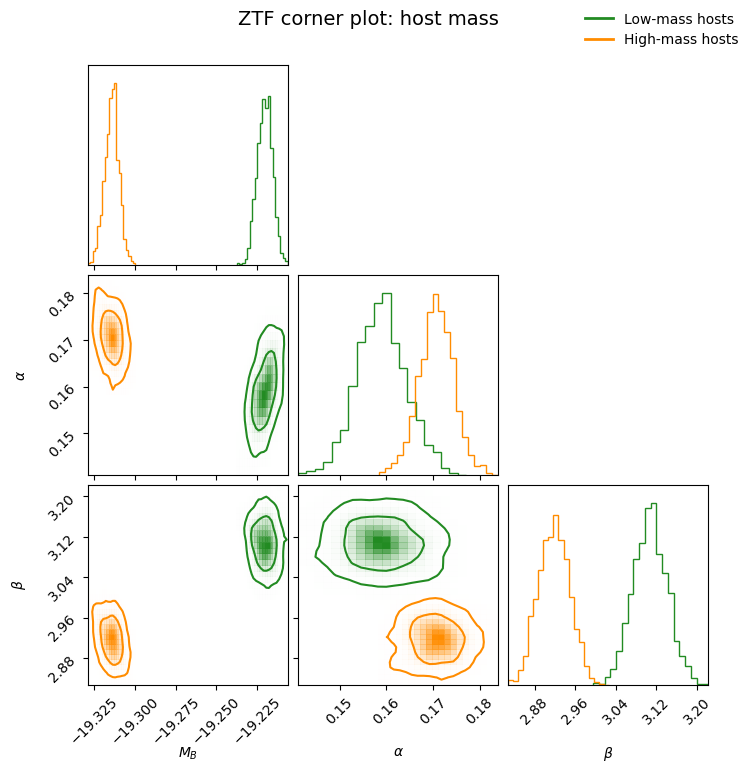

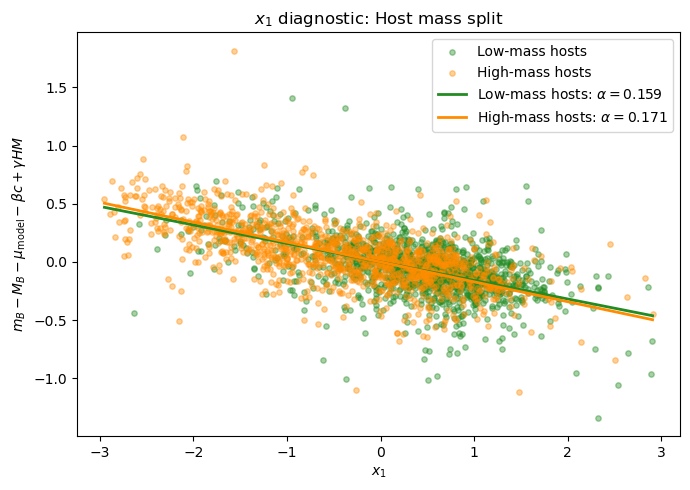

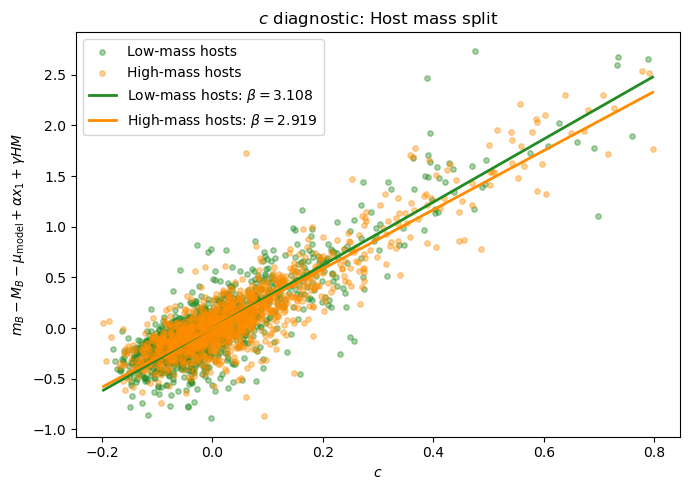

In [17]:
plot_overlaid_corner(
    low_mass_samples_3d,
    high_mass_samples_3d,
    "Low-mass hosts",
    "High-mass hosts",
    "ZTF corner plot: host mass",
    "forestgreen",
    "darkorange",
    filename=nonclipped_3d_dir / "ZTF_corner_host_mass_3d.png"
)

plot_mcmc_diagnostics_split(
    low_mass_df_3d,
    low_mass_samples_3d,
    high_mass_df_3d,
    high_mass_samples_3d,
    low_label="Low-mass hosts",
    high_label="High-mass hosts",
    low_color="forestgreen",
    high_color="darkorange",
    title="Host mass split",
    filename_prefix="ZTF_host_mass",
    clipped=False
)

In [18]:
all_sampler_3d, all_samples_3d = run_mcmc(
    all_data_3d,
    initial_guess_3d,
    nwalkers=nwalkers,
    nsteps=nsteps,
    burnin=burnin,
    thin=thin,
    random_seed=175
)

all_summary_3d = summarize_samples(
    "All ZTF supernovae: 3-parameter LambdaCDM",
    all_samples_3d,
    filename=nonclipped_3d_dir / "ZTF_all_3d.txt"
)

np.save(nonclipped_3d_dir / "ZTF_all_samples_3d.npy", all_samples_3d)
np.save(nonclipped_3d_dir / "ZTF_all_chain_3d.npy", all_sampler_3d.get_chain())

100%|██████████████████████████████████████| 1000/1000 [02:11<00:00,  7.60it/s]


All ZTF supernovae: 3-parameter LambdaCDM
M_B = -19.2662 -0.0028 +0.0027
alpha = 0.1487 -0.0030 +0.0026
beta = 2.9649 -0.0218 +0.0211


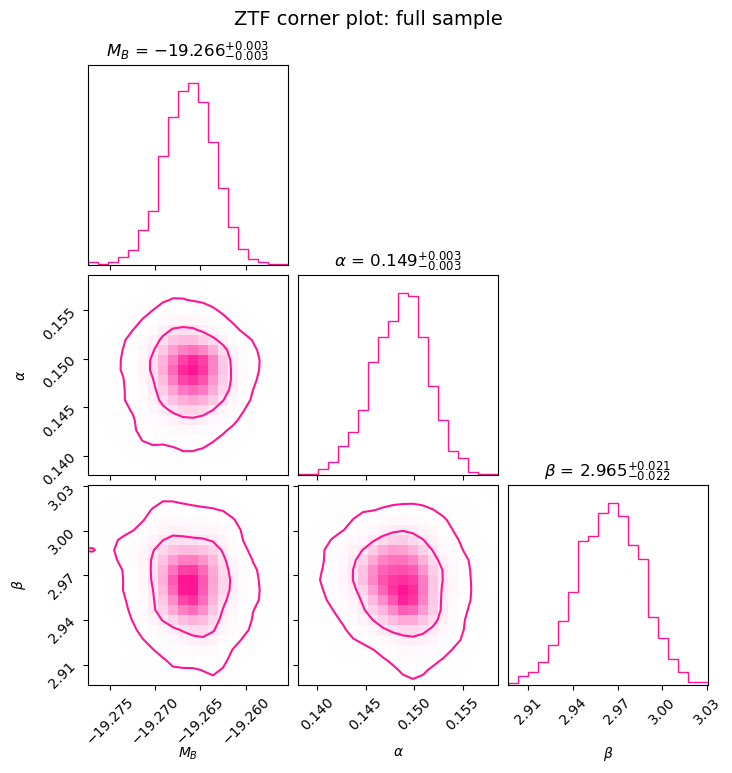

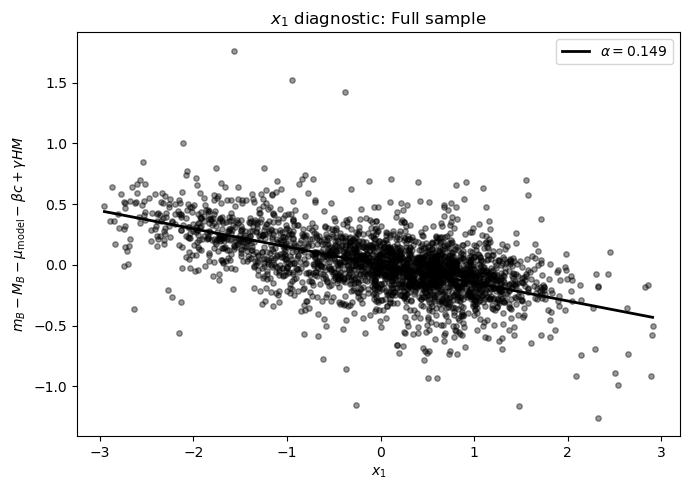

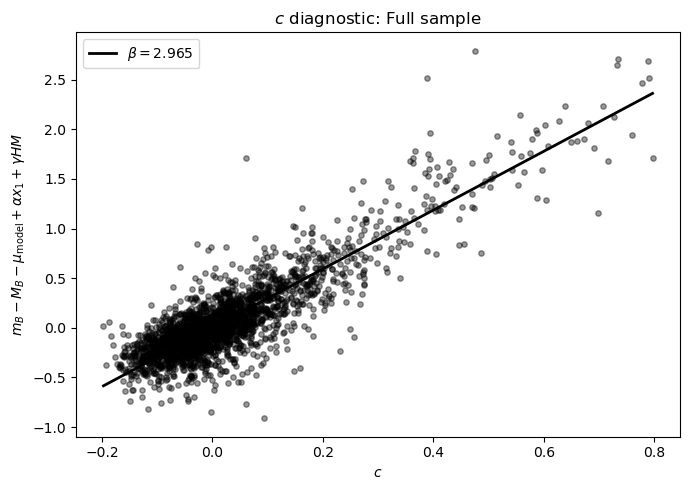

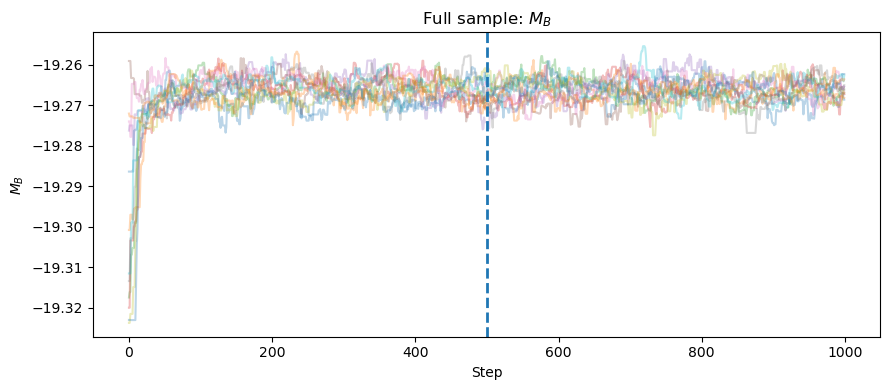

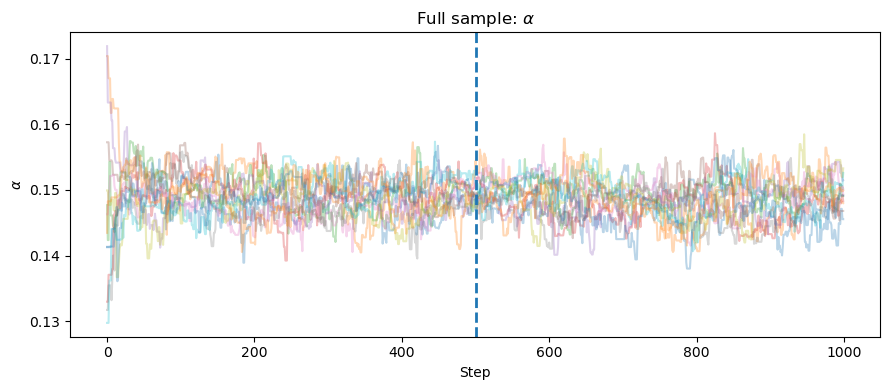

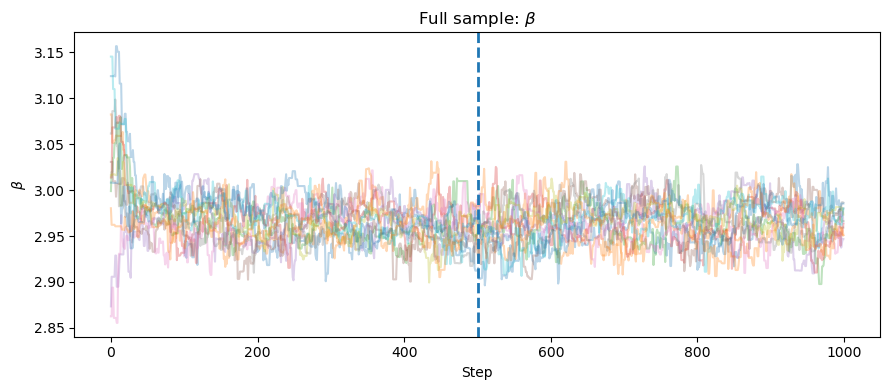

In [19]:
fig = corner.corner(
    all_samples_3d,
    labels=[
        r"$M_B$",
        r"$\alpha$",
        r"$\beta$",
    ],
    levels=(0.683, 0.954),
    color="deeppink",
    plot_datapoints=False,
    plot_density=True,
    fill_contours=False,
    smooth=1.0,
    show_titles=True,
    title_fmt=".3f"
)

fig.suptitle("ZTF corner plot: full sample", fontsize=14, y=1.02)

fig.savefig(
    nonclipped_3d_dir / "ZTF_corner_full_sample_3d.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plot_mcmc_diagnostics(
    ztf_sample_3d,
    all_samples_3d,
    title="Full sample",
    filename_prefix="ZTF_full_sample",
    clipped=False
)

plot_burnin_diagnostics(
    all_sampler_3d,
    burnin=burnin,
    title="Full sample",
    filename_prefix="ZTF_full_sample",
    clipped=False
)

## Non-Clipped 4D Fits

Fit $M_B$, $\alpha$, $\beta$, and $\gamma$, with $H_0$ fixed.

In [20]:
blue_sampler_4d, blue_samples_4d = run_mcmc(
    blue_data_4d,
    initial_guess_4d,
    nwalkers=nwalkers,
    nsteps=nsteps,
    burnin=burnin,
    thin=thin,
    random_seed=171
)

blue_summary_4d = summarize_samples(
    "Blue hosts: 4-parameter LambdaCDM",
    blue_samples_4d,
    filename=nonclipped_4d_dir / "ZTF_blue_4d.txt"
)

red_sampler_4d, red_samples_4d = run_mcmc(
    red_data_4d,
    initial_guess_4d,
    nwalkers=nwalkers,
    nsteps=nsteps,
    burnin=burnin,
    thin=thin,
    random_seed=172
)

red_summary_4d = summarize_samples(
    "Red hosts: 4-parameter LambdaCDM",
    red_samples_4d,
    filename=nonclipped_4d_dir / "ZTF_red_4d.txt"
)

np.save(nonclipped_4d_dir / "ZTF_blue_samples_4d.npy", blue_samples_4d)
np.save(nonclipped_4d_dir / "ZTF_red_samples_4d.npy", red_samples_4d)

100%|██████████████████████████████████████| 1000/1000 [01:37<00:00, 10.21it/s]



Blue hosts: 4-parameter LambdaCDM
M_B = -19.1948 -0.0054 +0.0046
alpha = 0.1807 -0.0062 +0.0056
beta = 3.1215 -0.0364 +0.0388
gamma = 0.0859 -0.0101 +0.0102


100%|██████████████████████████████████████| 1000/1000 [01:41<00:00,  9.85it/s]


Red hosts: 4-parameter LambdaCDM
M_B = -19.2717 -0.0095 +0.0089
alpha = 0.1702 -0.0041 +0.0037
beta = 2.9322 -0.0271 +0.0268
gamma = 0.0537 -0.0100 +0.0102


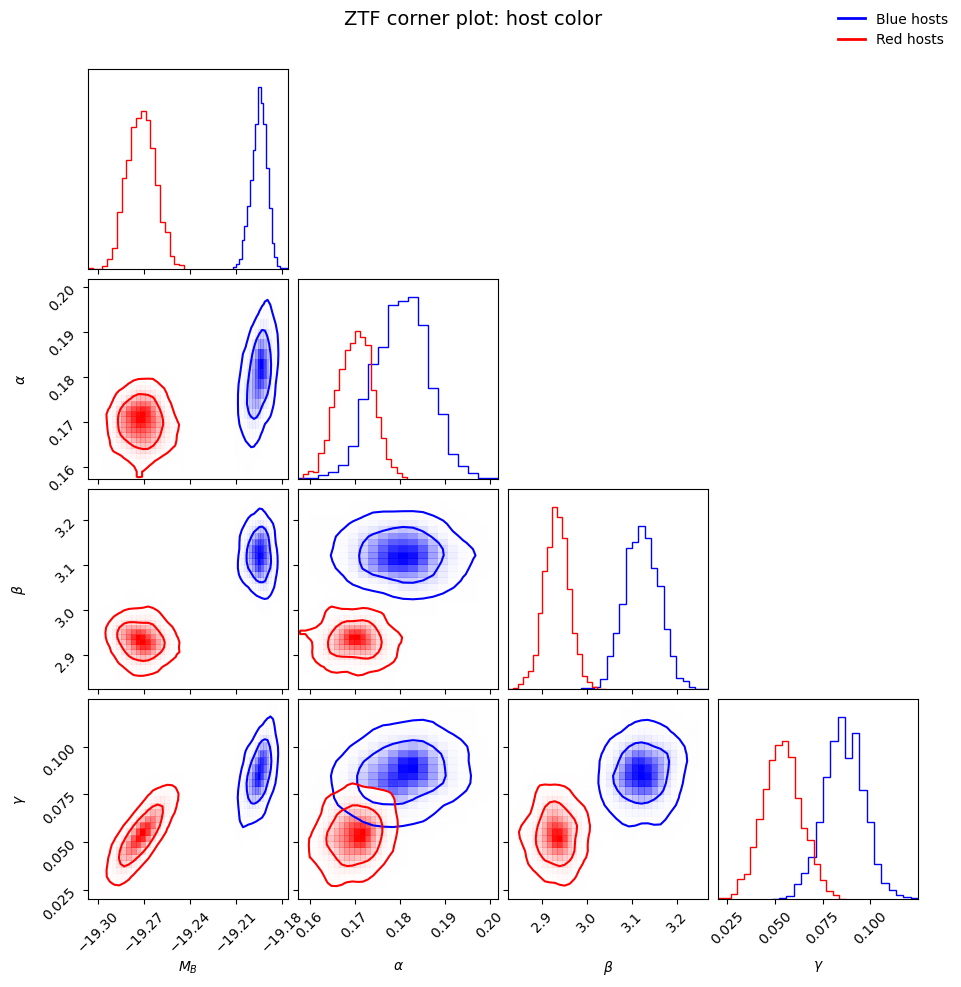

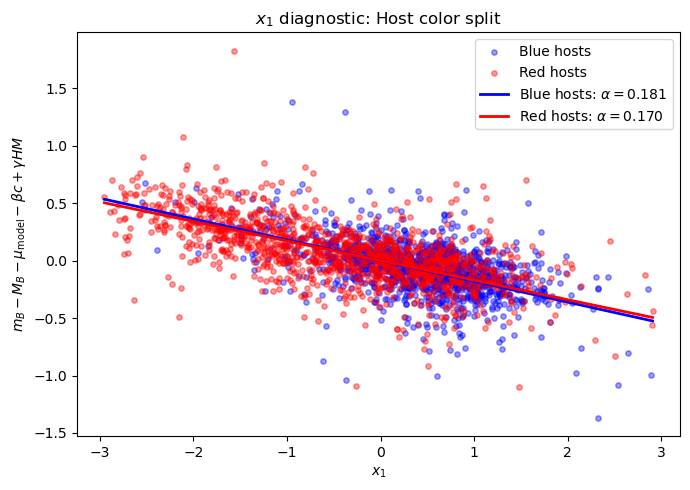

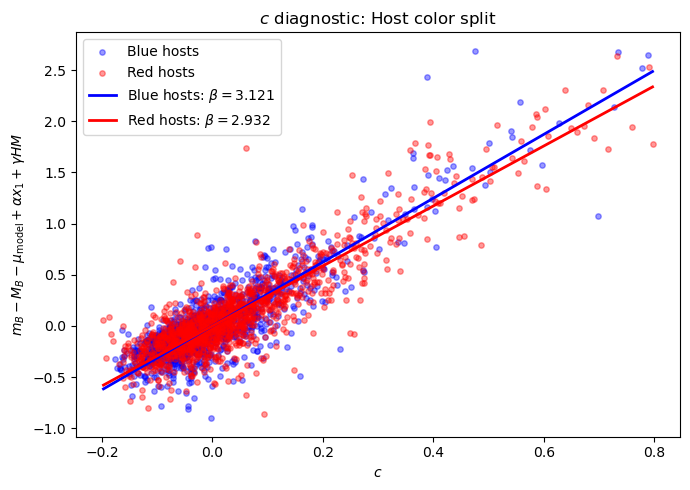

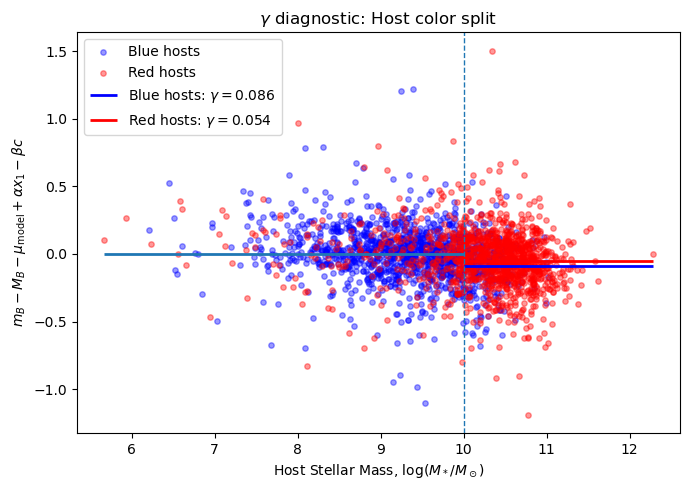

In [25]:
plot_overlaid_corner(
    blue_samples_4d,
    red_samples_4d,
    "Blue hosts",
    "Red hosts",
    "ZTF corner plot: host color",
    "blue",
    "red",
    filename=nonclipped_4d_dir / "ZTF_corner_host_color_4d.png"
)

plot_mcmc_diagnostics_split(
    blue_df_4d,
    blue_samples_4d,
    red_df_4d,
    red_samples_4d,
    low_label="Blue hosts",
    high_label="Red hosts",
    low_color="blue",
    high_color="red",
    title="Host color split",
    filename_prefix="ZTF_host_color",
    clipped=False
)

In [26]:
all_sampler_4d, all_samples_4d = run_mcmc(
    all_data_4d,
    initial_guess_4d,
    nwalkers=nwalkers,
    nsteps=nsteps,
    burnin=burnin,
    thin=thin,
    random_seed=175
)

all_summary_4d = summarize_samples(
    "All ZTF supernovae: 4-parameter LambdaCDM",
    all_samples_4d,
    filename=nonclipped_4d_dir / "ZTF_all_4d.txt"
)

np.save(nonclipped_4d_dir / "ZTF_all_samples_4d.npy", all_samples_4d)
np.save(nonclipped_4d_dir / "ZTF_all_chain_4d.npy", all_sampler_4d.get_chain())

100%|██████████████████████████████████████| 1000/1000 [02:47<00:00,  5.98it/s]


All ZTF supernovae: 4-parameter LambdaCDM
M_B = -19.2171 -0.0041 +0.0043
alpha = 0.1674 -0.0029 +0.0029
beta = 2.9974 -0.0226 +0.0218
gamma = 0.0990 -0.0058 +0.0062


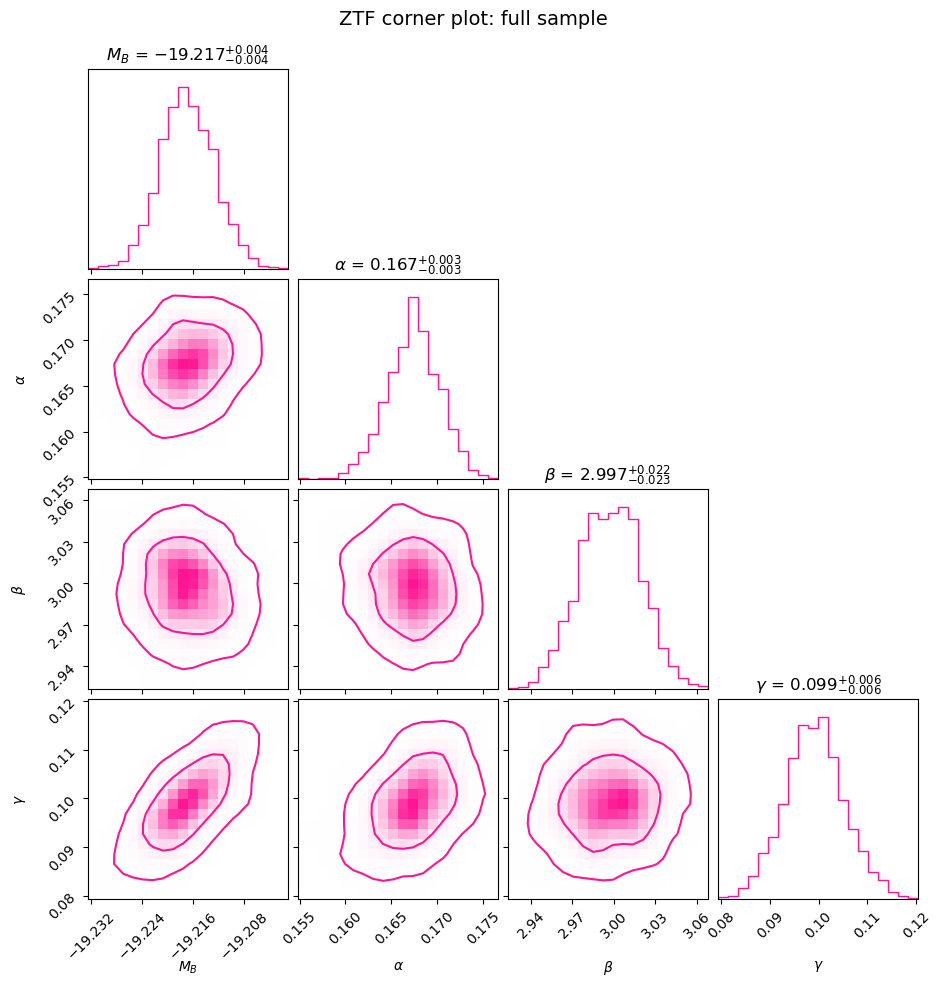

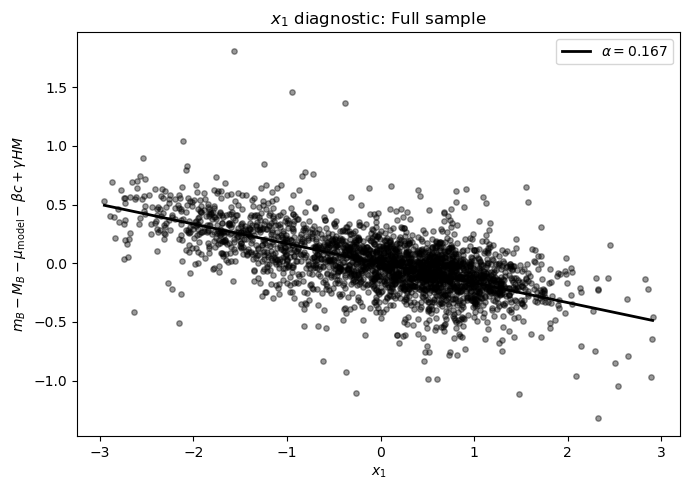

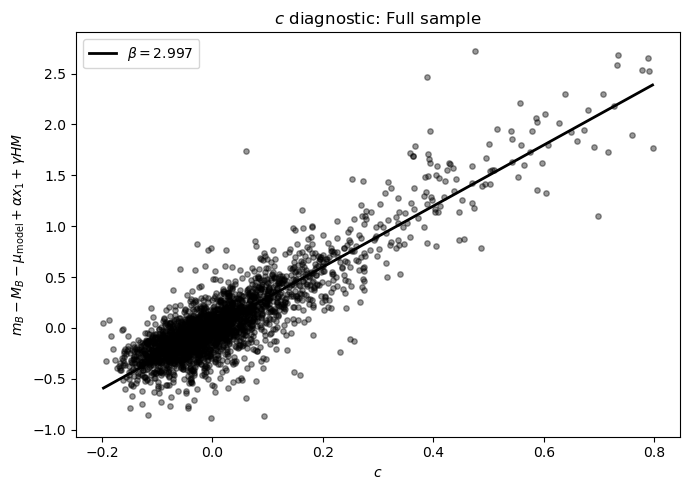

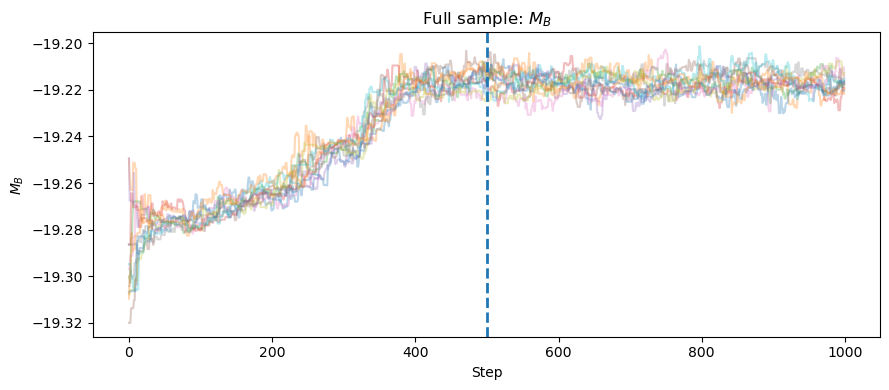

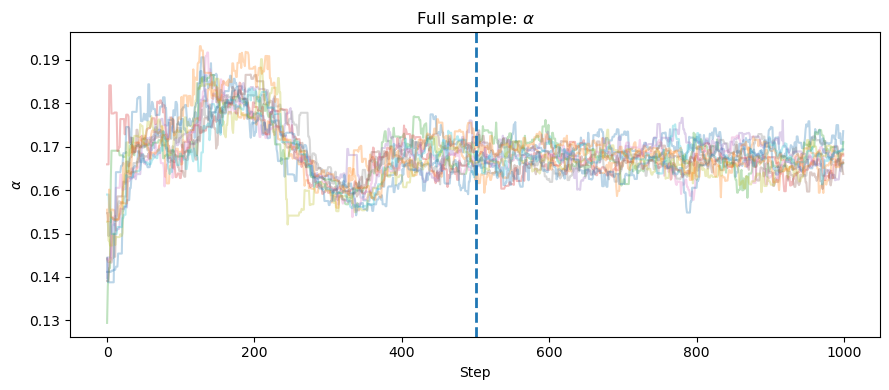

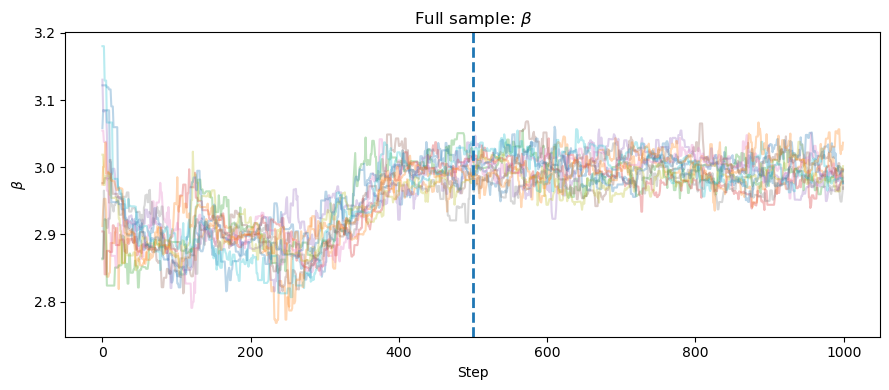

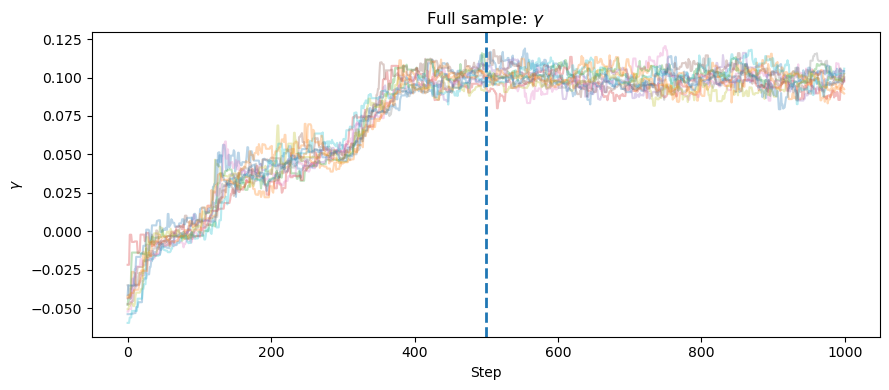

In [29]:
fig = corner.corner(
    all_samples_4d,
    labels=[
        r"$M_B$",
        r"$\alpha$",
        r"$\beta$",
        r"$\gamma$"
    ],
    levels=(0.683, 0.954),
    color="deeppink",
    plot_datapoints=False,
    plot_density=True,
    fill_contours=False,
    smooth=1.0,
    show_titles=True,
    title_fmt=".3f"
)

fig.suptitle("ZTF corner plot: full sample", fontsize=14, y=1.02)

fig.savefig(
    nonclipped_4d_dir / "ZTF_corner_full_sample_4d.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plot_mcmc_diagnostics(
    ztf_sample_4d,
    all_samples_4d,
    title="Full sample",
    filename_prefix="ZTF_full_sample",
    clipped=False
)

plot_burnin_diagnostics(
    all_sampler_4d,
    burnin=burnin,
    title="Full sample",
    filename_prefix="ZTF_full_sample",
    clipped=False
)

# 2.5-Sigma Clipping

- **3D:** uses the median `all_samples_3d` values of $M_B$, $\alpha$, $\beta$.
- **4D:** uses the median `all_samples_4d` values of $M_B$, $\alpha$, $\beta$, and $\gamma$.

In [31]:
# =====================================================
# 3D clipping from the non-clipped 3D fit
# Parameters: M_B, alpha, beta
# H0 is fixed at H_0
# =====================================================

M_B_clip_3d = np.median(all_samples_3d[:, 0])
alpha_clip_3d = np.median(all_samples_3d[:, 1])
beta_clip_3d = np.median(all_samples_3d[:, 2])

cosmology_clip_3d = LambdaCDM(
    H0=H_0,
    Om0=0.3,
    Ode0=0.7
)

ztf_sample_clipped_3d = ztf_sample_3d.copy()
ztf_sample_clipped_3d["MU_OBS"] = (
    ztf_sample_clipped_3d["mB"]
    - M_B_clip_3d
    + alpha_clip_3d * ztf_sample_clipped_3d["x1"]
    - beta_clip_3d * ztf_sample_clipped_3d["c"]
)

ztf_sample_clipped_3d["MU_PRED"] = cosmology_clip_3d.distmod(ztf_sample_clipped_3d["zHD"].to_numpy()).value
ztf_sample_clipped_3d["RESIDUAL"] = ztf_sample_clipped_3d["MU_OBS"] - ztf_sample_clipped_3d["MU_PRED"]

ztf_sample_clipped_3d["VARIANCE"] = (
    ztf_sample_clipped_3d["mB_err"]**2
    + alpha_clip_3d**2 * ztf_sample_clipped_3d["x1_err"]**2
    + beta_clip_3d**2 * ztf_sample_clipped_3d["c_err"]**2
    + 2.0 * alpha_clip_3d * ztf_sample_clipped_3d["COV_mB_x1"]
    - 2.0 * beta_clip_3d * ztf_sample_clipped_3d["COV_mB_c"]
    - 2.0 * alpha_clip_3d * beta_clip_3d * ztf_sample_clipped_3d["COV_x1_c"]
    + ztf_sample_clipped_3d["MUERR_VPEC"]**2
    + ztf_sample_clipped_3d["LENSDMUERR"]**2
    + sigma_int**2
)

ztf_sample_clipped_3d["SIGMA_TOTAL"] = np.sqrt(ztf_sample_clipped_3d["VARIANCE"])
ztf_sample_clipped_3d["SIGMA_RESIDUAL"] = ztf_sample_clipped_3d["RESIDUAL"] / ztf_sample_clipped_3d["SIGMA_TOTAL"]

outliers_3d = ztf_sample_clipped_3d[np.abs(ztf_sample_clipped_3d["SIGMA_RESIDUAL"]) > sigma_cut].copy()
ztf_sample_clipped_3d = ztf_sample_clipped_3d[np.abs(ztf_sample_clipped_3d["SIGMA_RESIDUAL"]) <= sigma_cut].copy()


# =====================================================
# 4D clipping from the non-clipped 4D fit
# Parameters: M_B, alpha, beta, gamma
# H0 is fixed at H_0
# =====================================================

M_B_clip_4d = np.median(all_samples_4d[:, 0])
alpha_clip_4d = np.median(all_samples_4d[:, 1])
beta_clip_4d = np.median(all_samples_4d[:, 2])
gamma_clip_4d = np.median(all_samples_4d[:, 3])

cosmology_clip_4d = LambdaCDM(
    H0=H_0,
    Om0=0.3,
    Ode0=0.7
)

ztf_sample_clipped_4d = ztf_sample_4d.copy()
HM_clip_4d = (ztf_sample_clipped_4d["HOST_LOGMASS"] >= mass_cut).astype(float)

ztf_sample_clipped_4d["MU_OBS"] = (
    ztf_sample_clipped_4d["mB"]
    - M_B_clip_4d
    + alpha_clip_4d * ztf_sample_clipped_4d["x1"]
    - beta_clip_4d * ztf_sample_clipped_4d["c"]
    + gamma_clip_4d * HM_clip_4d
)

ztf_sample_clipped_4d["MU_PRED"] = cosmology_clip_4d.distmod(ztf_sample_clipped_4d["zHD"].to_numpy()).value
ztf_sample_clipped_4d["RESIDUAL"] = ztf_sample_clipped_4d["MU_OBS"] - ztf_sample_clipped_4d["MU_PRED"]

ztf_sample_clipped_4d["VARIANCE"] = (
    ztf_sample_clipped_4d["mB_err"]**2
    + alpha_clip_4d**2 * ztf_sample_clipped_4d["x1_err"]**2
    + beta_clip_4d**2 * ztf_sample_clipped_4d["c_err"]**2
    + 2.0 * alpha_clip_4d * ztf_sample_clipped_4d["COV_mB_x1"]
    - 2.0 * beta_clip_4d * ztf_sample_clipped_4d["COV_mB_c"]
    - 2.0 * alpha_clip_4d * beta_clip_4d * ztf_sample_clipped_4d["COV_x1_c"]
    + ztf_sample_clipped_4d["MUERR_VPEC"]**2
    + ztf_sample_clipped_4d["LENSDMUERR"]**2
    + sigma_int**2
)

ztf_sample_clipped_4d["SIGMA_TOTAL"] = np.sqrt(ztf_sample_clipped_4d["VARIANCE"])
ztf_sample_clipped_4d["SIGMA_RESIDUAL"] = ztf_sample_clipped_4d["RESIDUAL"] / ztf_sample_clipped_4d["SIGMA_TOTAL"]

outliers_4d = ztf_sample_clipped_4d[np.abs(ztf_sample_clipped_4d["SIGMA_RESIDUAL"]) > sigma_cut].copy()
ztf_sample_clipped_4d = ztf_sample_clipped_4d[np.abs(ztf_sample_clipped_4d["SIGMA_RESIDUAL"]) <= sigma_cut].copy()

print(f"3D: {len(ztf_sample_3d)} -> {len(ztf_sample_clipped_3d)} ({len(outliers_3d)} removed)")
print(f"4D: {len(ztf_sample_4d)} -> {len(ztf_sample_clipped_4d)} ({len(outliers_4d)} removed)")

3D: 2547 -> 2386 (161 removed)
4D: 2547 -> 2406 (141 removed)


In [32]:
# =====================================================
# 3D clipped splits and tuples
# =====================================================

clipped_low_mass_df_3d = ztf_sample_clipped_3d[ztf_sample_clipped_3d["HOST_LOGMASS"] < mass_cut].copy()
clipped_high_mass_df_3d = ztf_sample_clipped_3d[ztf_sample_clipped_3d["HOST_LOGMASS"] >= mass_cut].copy()

clipped_all_data_3d = make_data_tuple(ztf_sample_clipped_3d, nparam=3)
clipped_low_mass_data_3d = make_data_tuple(clipped_low_mass_df_3d, nparam=3)
clipped_high_mass_data_3d = make_data_tuple(clipped_high_mass_df_3d, nparam=3)


# =====================================================
# 4D clipped splits and tuples
# =====================================================

clipped_blue_df_4d = ztf_sample_clipped_4d[ztf_sample_clipped_4d["HOST_COLOR"] < color_cut].copy()
clipped_red_df_4d = ztf_sample_clipped_4d[ztf_sample_clipped_4d["HOST_COLOR"] >= color_cut].copy()

clipped_all_data_4d = make_data_tuple(ztf_sample_clipped_4d, nparam=4)
clipped_blue_data_4d = make_data_tuple(clipped_blue_df_4d, nparam=4)
clipped_red_data_4d = make_data_tuple(clipped_red_df_4d, nparam=4)

## Clipped 3D Fits

In [33]:
clipped_low_mass_sampler_3d, clipped_low_mass_samples_3d = run_mcmc(
    clipped_low_mass_data_3d,
    initial_guess_3d,
    nwalkers=nwalkers,
    nsteps=nsteps,
    burnin=burnin,
    thin=thin,
    random_seed=151
)

clipped_low_mass_summary_3d = summarize_samples(
    "Low-mass hosts: clipped 3-parameter LambdaCDM",
    clipped_low_mass_samples_3d,
    filename=clipped_3d_dir / "ZTF_low_mass_3d_clipped.txt"
)

clipped_high_mass_sampler_3d, clipped_high_mass_samples_3d = run_mcmc(
    clipped_high_mass_data_3d,
    initial_guess_3d,
    nwalkers=nwalkers,
    nsteps=nsteps,
    burnin=burnin,
    thin=thin,
    random_seed=152
)

clipped_high_mass_summary_3d = summarize_samples(
    "High-mass hosts: clipped 3-parameter LambdaCDM",
    clipped_high_mass_samples_3d,
    filename=clipped_3d_dir / "ZTF_high_mass_3d_clipped.txt"
)

np.save(clipped_3d_dir / "ZTF_clipped_low_mass_samples_3d.npy", clipped_low_mass_samples_3d)
np.save(clipped_3d_dir / "ZTF_clipped_high_mass_samples_3d.npy", clipped_high_mass_samples_3d)

100%|██████████████████████████████████████| 1000/1000 [01:47<00:00,  9.32it/s]



Low-mass hosts: clipped 3-parameter LambdaCDM
M_B = -19.2274 -0.0046 +0.0046
alpha = 0.1390 -0.0050 +0.0045
beta = 2.8375 -0.0368 +0.0350


100%|██████████████████████████████████████| 1000/1000 [01:41<00:00,  9.86it/s]


High-mass hosts: clipped 3-parameter LambdaCDM
M_B = -19.2911 -0.0043 +0.0048
alpha = 0.1572 -0.0043 +0.0039
beta = 2.9021 -0.0295 +0.0282


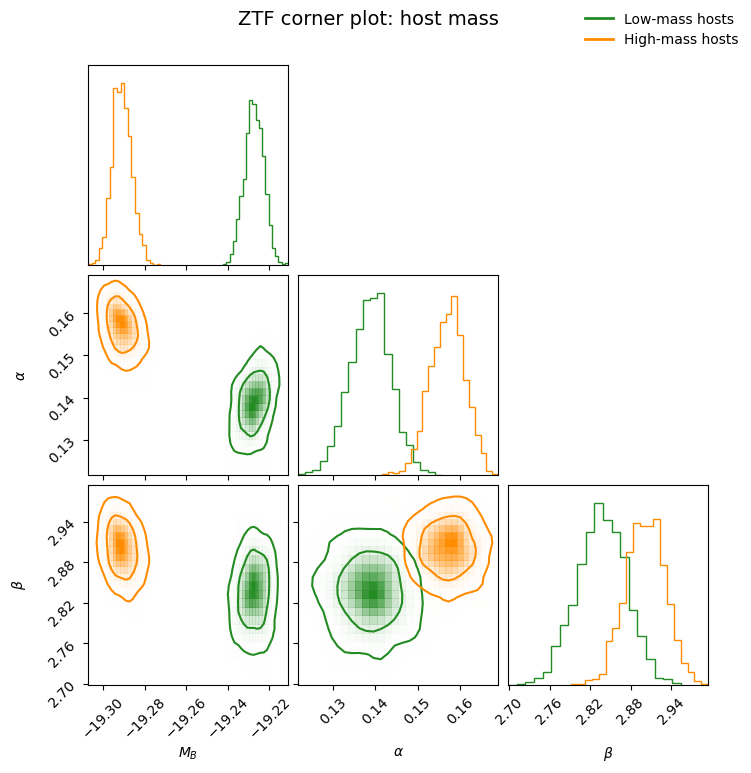

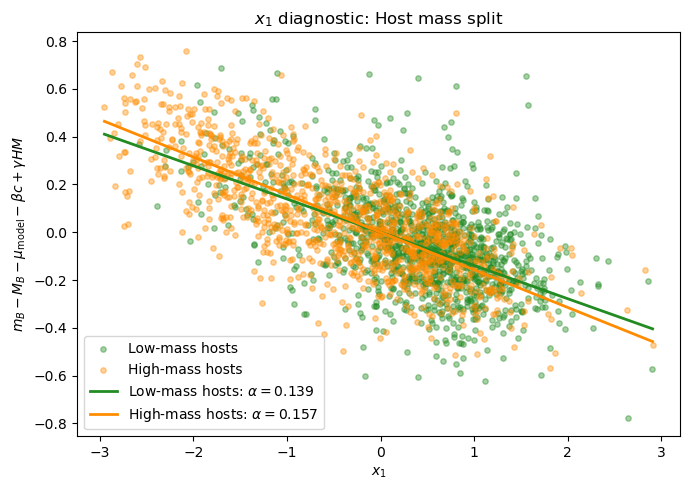

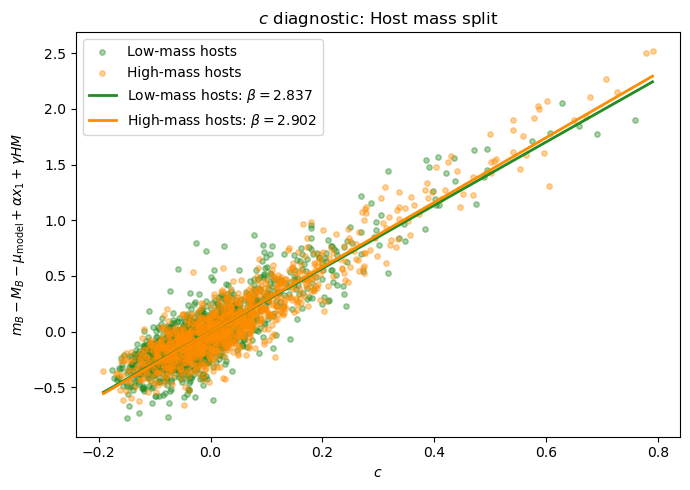

In [34]:
plot_overlaid_corner(
    clipped_low_mass_samples_3d,
    clipped_high_mass_samples_3d,
    "Low-mass hosts",
    "High-mass hosts",
    "ZTF corner plot: host mass",
    "forestgreen",
    "darkorange",
    filename=clipped_3d_dir / "ZTF_clipped_corner_host_mass_3d.png"
)

plot_mcmc_diagnostics_split(
    clipped_low_mass_df_3d,
    clipped_low_mass_samples_3d,
    clipped_high_mass_df_3d,
    clipped_high_mass_samples_3d,
    low_label="Low-mass hosts",
    high_label="High-mass hosts",
    low_color="forestgreen",
    high_color="darkorange",
    title="Host mass split",
    filename_prefix="ZTF_host_mass",
    clipped=True
)

In [35]:
clipped_all_sampler_3d, clipped_all_samples_3d = run_mcmc(
    clipped_all_data_3d,
    initial_guess_3d,
    nwalkers=nwalkers,
    nsteps=nsteps,
    burnin=burnin,
    thin=thin,
    random_seed=156
)

clipped_all_summary_3d = summarize_samples(
    "All ZTF supernovae: clipped 3-parameter LambdaCDM",
    clipped_all_samples_3d,
    filename=clipped_3d_dir / "ZTF_clipped_all_3d.txt"
)

np.save(clipped_3d_dir / "ZTF_clipped_all_samples_3d.npy", clipped_all_samples_3d)
np.save(clipped_3d_dir / "ZTF_clipped_all_chain_3d.npy", clipped_all_sampler_3d.get_chain())

100%|██████████████████████████████████████| 1000/1000 [02:39<00:00,  6.26it/s]



All ZTF supernovae: clipped 3-parameter LambdaCDM
M_B = -19.2545 -0.0027 +0.0028
alpha = 0.1377 -0.0028 +0.0030
beta = 2.8405 -0.0229 +0.0245


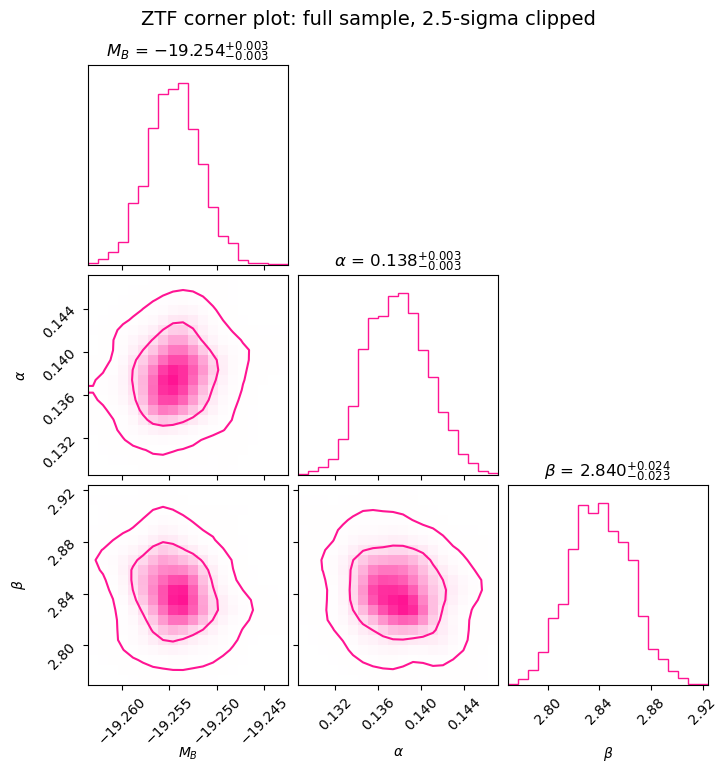

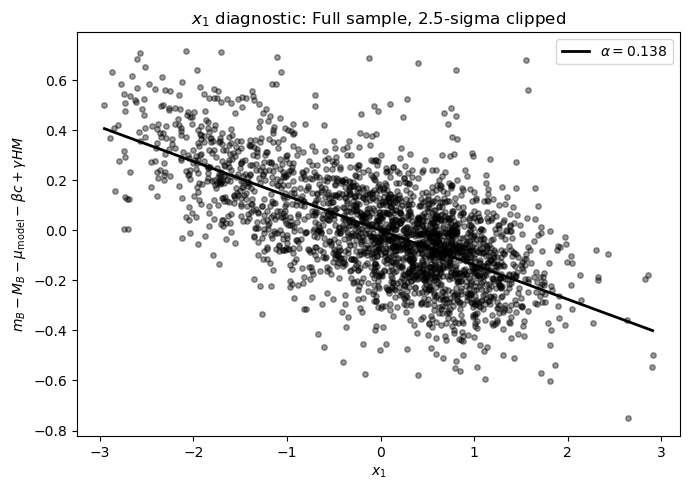

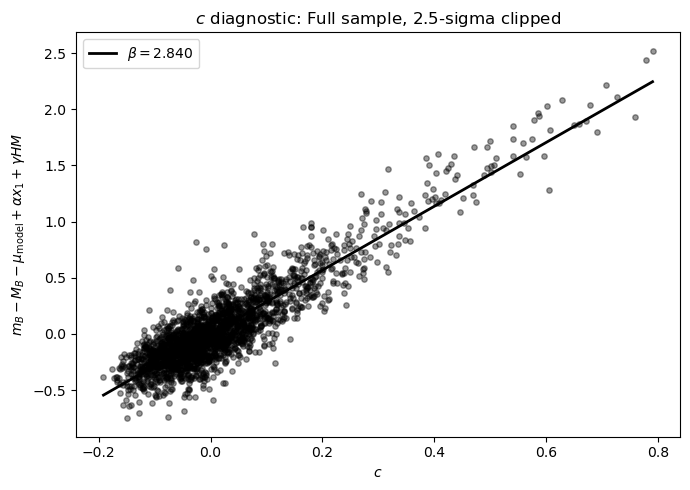

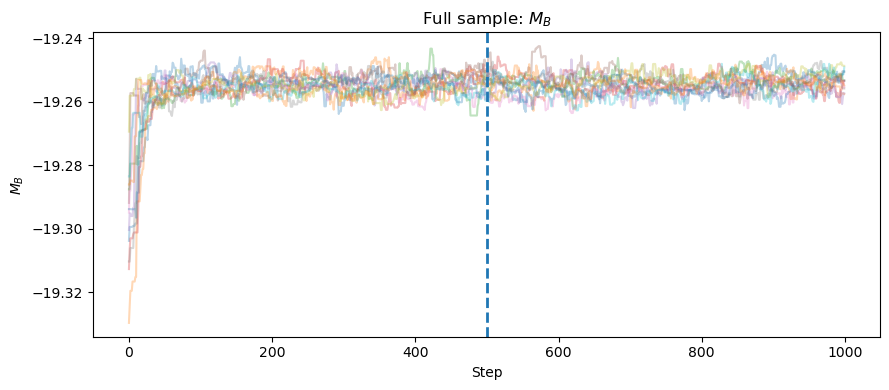

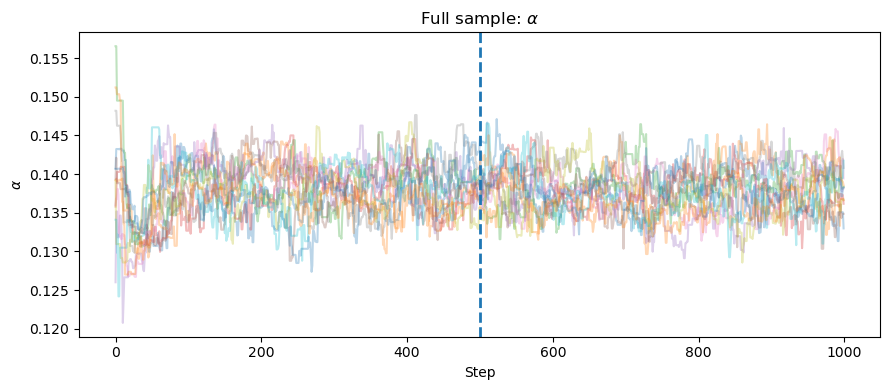

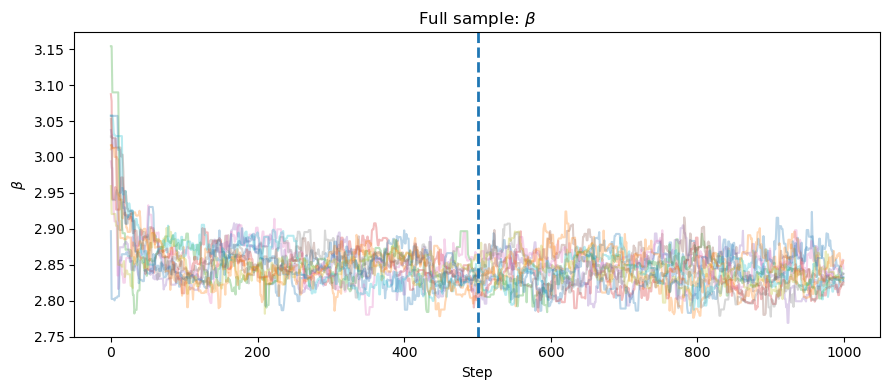

In [36]:
fig = corner.corner(
    clipped_all_samples_3d,
    labels=[
        r"$M_B$",
        r"$\alpha$",
        r"$\beta$",
    ],
    levels=(0.683, 0.954),
    color="deeppink",
    plot_datapoints=False,
    plot_density=True,
    fill_contours=False,
    smooth=1.0,
    show_titles=True,
    title_fmt=".3f"
)

fig.suptitle("ZTF corner plot: full sample, 2.5-sigma clipped", fontsize=14, y=1.02)

fig.savefig(
    clipped_3d_dir / "ZTF_clipped_corner_full_sample_3d.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plot_mcmc_diagnostics(
    ztf_sample_clipped_3d,
    clipped_all_samples_3d,
    title="Full sample, 2.5-sigma clipped",
    filename_prefix="ZTF_full_sample",
    clipped=True
)

plot_burnin_diagnostics(
    clipped_all_sampler_3d,
    burnin=burnin,
    title="Full sample",
    filename_prefix="ZTF_full_sample",
    clipped=True
)

## Clipped 4D Fits

In [37]:
clipped_blue_sampler_4d, clipped_blue_samples_4d = run_mcmc(
    clipped_blue_data_4d,
    initial_guess_4d,
    nwalkers=nwalkers,
    nsteps=nsteps,
    burnin=burnin,
    thin=thin,
    random_seed=171
)

clipped_blue_summary_4d = summarize_samples(
    "Blue hosts: clipped 4-parameter LambdaCDM",
    clipped_blue_samples_4d,
    filename=clipped_4d_dir / "ZTF_blue_4d_clipped.txt"
)

clipped_red_sampler_4d, clipped_red_samples_4d = run_mcmc(
    clipped_red_data_4d,
    initial_guess_4d,
    nwalkers=nwalkers,
    nsteps=nsteps,
    burnin=burnin,
    thin=thin,
    random_seed=172
)

clipped_red_summary_4d = summarize_samples(
    "Red hosts: clipped 4-parameter LambdaCDM",
    clipped_red_samples_4d,
    filename=clipped_4d_dir / "ZTF_red_4d_clipped.txt"
)

np.save(clipped_4d_dir / "ZTF_clipped_blue_samples_4d.npy", clipped_blue_samples_4d)
np.save(clipped_4d_dir / "ZTF_clipped_red_samples_4d.npy", clipped_red_samples_4d)

100%|██████████████████████████████████████| 1000/1000 [01:45<00:00,  9.46it/s]



Blue hosts: clipped 4-parameter LambdaCDM
M_B = -19.2006 -0.0052 +0.0052
alpha = 0.1538 -0.0056 +0.0059
beta = 2.9347 -0.0356 +0.0335
gamma = 0.0681 -0.0102 +0.0113


100%|██████████████████████████████████████| 1000/1000 [01:44<00:00,  9.61it/s]


Red hosts: clipped 4-parameter LambdaCDM
M_B = -19.2510 -0.0078 +0.0083
alpha = 0.1604 -0.0043 +0.0040
beta = 2.8806 -0.0309 +0.0306
gamma = 0.0581 -0.0095 +0.0106


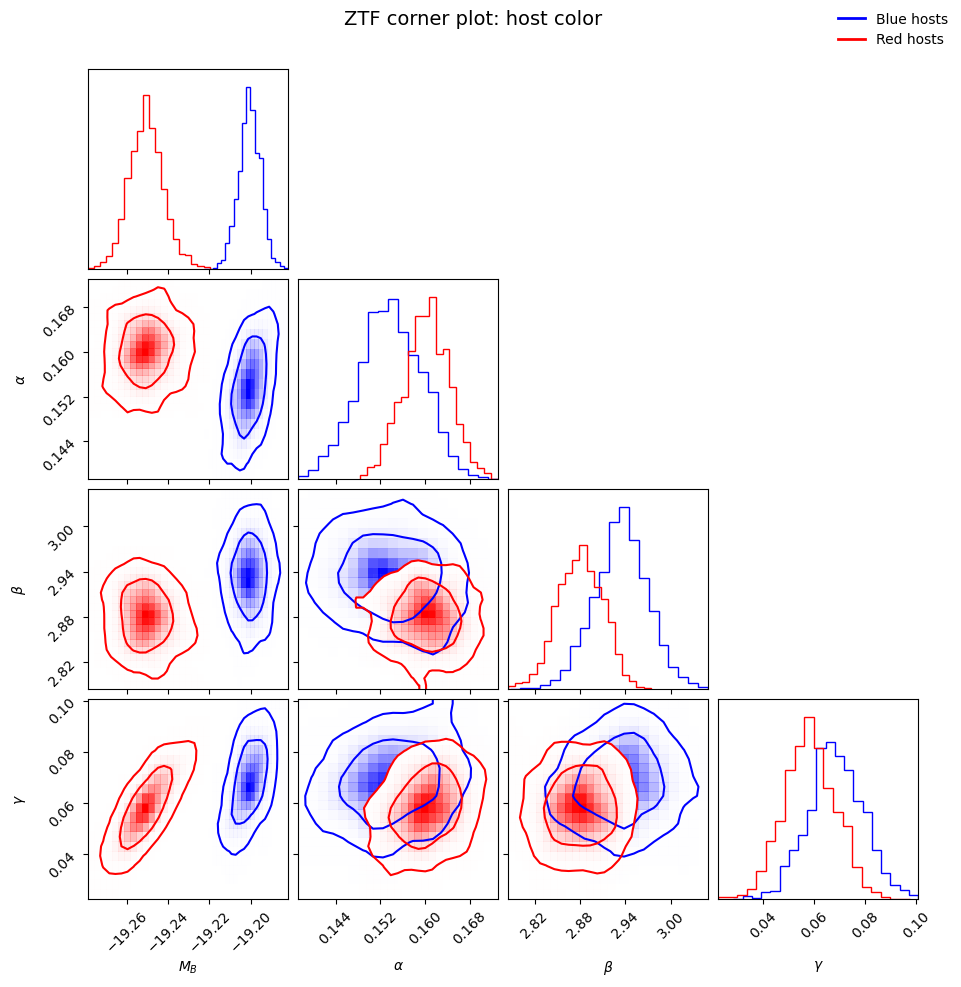

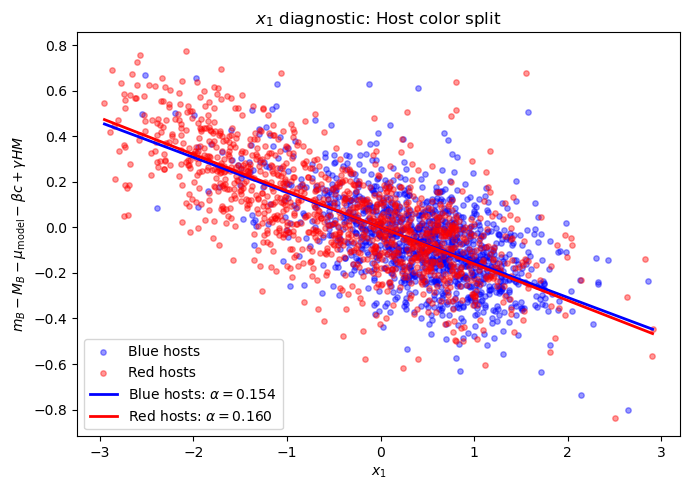

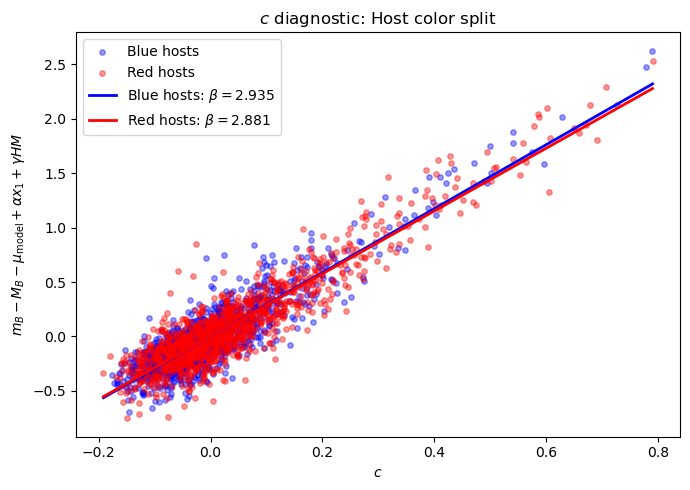

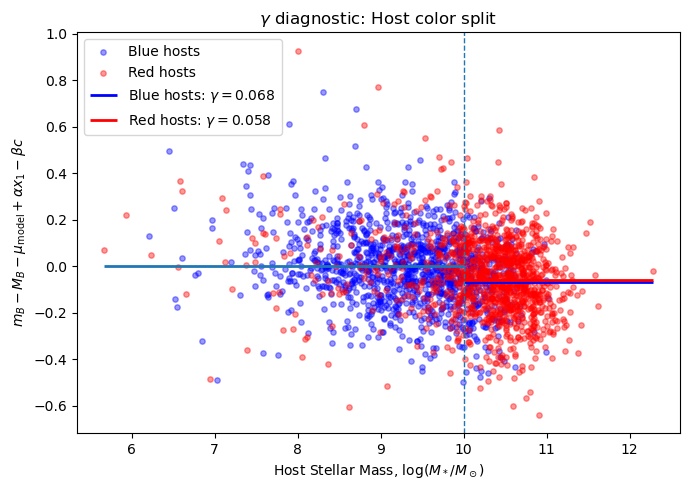

In [38]:
plot_overlaid_corner(
    clipped_blue_samples_4d,
    clipped_red_samples_4d,
    "Blue hosts",
    "Red hosts",
    "ZTF corner plot: host color",
    "blue",
    "red",
    filename=clipped_4d_dir / "ZTF_clipped_corner_host_color_4d.png"
)


plot_mcmc_diagnostics_split(
    clipped_blue_df_4d,
    clipped_blue_samples_4d,
    clipped_red_df_4d,
    clipped_red_samples_4d,
    low_label="Blue hosts",
    high_label="Red hosts",
    low_color="blue",
    high_color="red",
    title="Host color split",
    filename_prefix="ZTF_host_color",
    clipped=True
)

In [39]:
clipped_all_sampler_4d, clipped_all_samples_4d = run_mcmc(
    clipped_all_data_4d,
    initial_guess_4d,
    nwalkers=nwalkers,
    nsteps=nsteps,
    burnin=burnin,
    thin=thin,
    random_seed=175
)

clipped_all_summary_4d = summarize_samples(
    "All ZTF supernovae: clipped 4-parameter LambdaCDM",
    clipped_all_samples_4d,
    filename=clipped_4d_dir / "ZTF_clipped_all_4d.txt"
)

np.save(clipped_4d_dir / "ZTF_clipped_all_samples_4d.npy", clipped_all_samples_4d)
np.save(clipped_4d_dir / "ZTF_clipped_all_chain_4d.npy", clipped_all_sampler_4d.get_chain())

100%|██████████████████████████████████████| 1000/1000 [02:29<00:00,  6.68it/s]


All ZTF supernovae: clipped 4-parameter LambdaCDM
M_B = -19.2118 -0.0046 +0.0044
alpha = 0.1539 -0.0029 +0.0034
beta = 2.9018 -0.0199 +0.0198
gamma = 0.0873 -0.0070 +0.0062


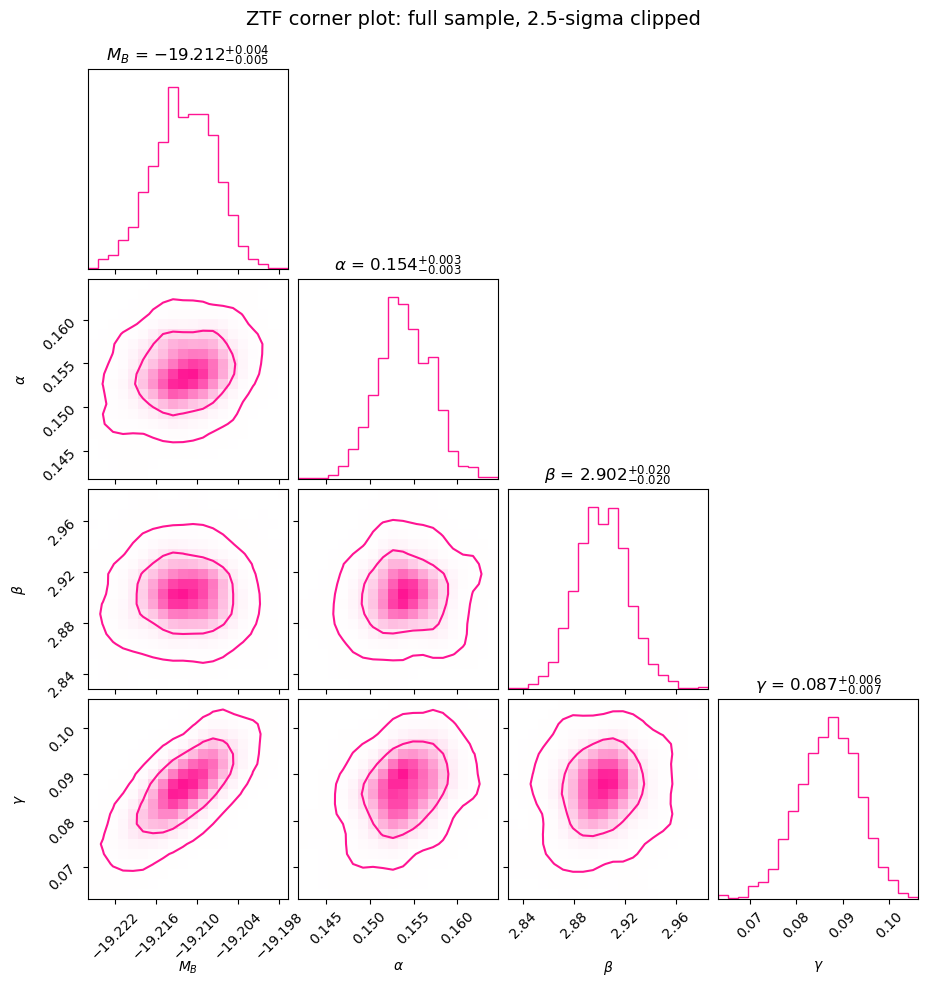

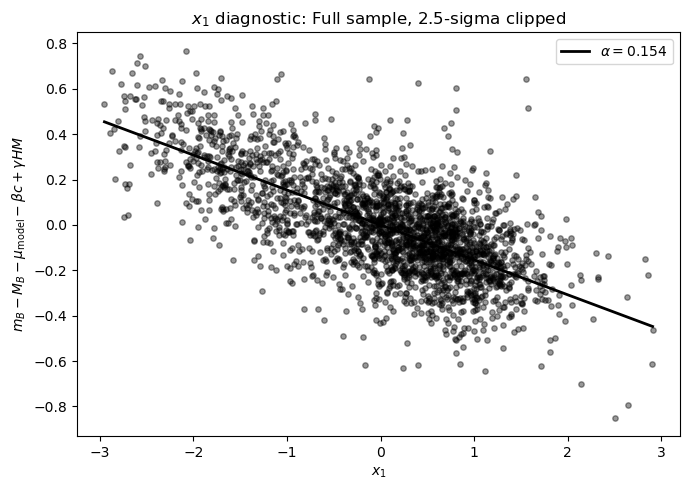

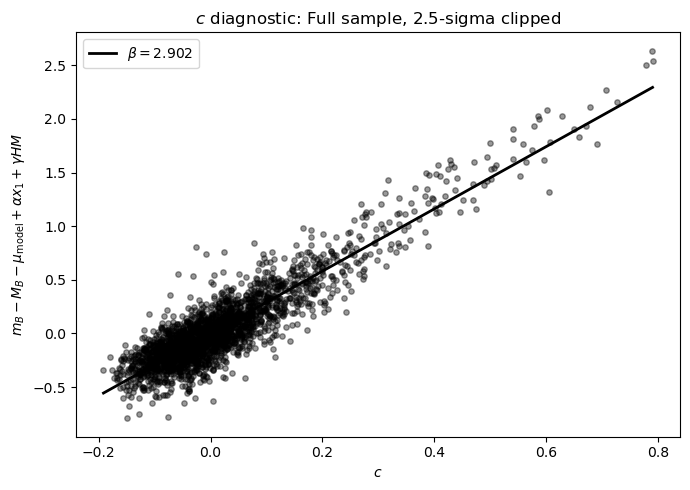

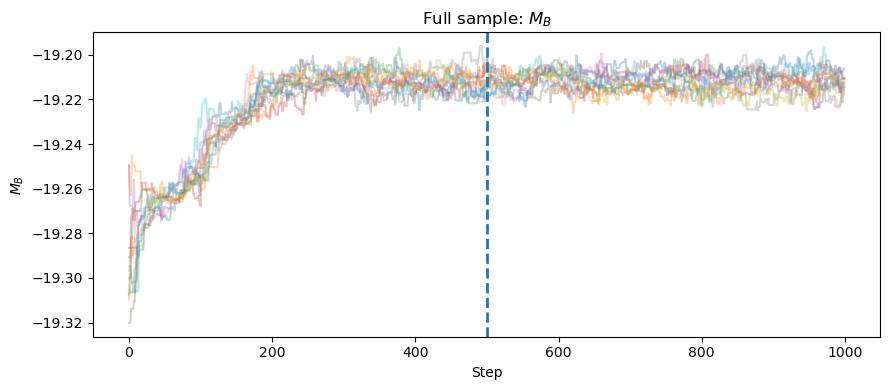

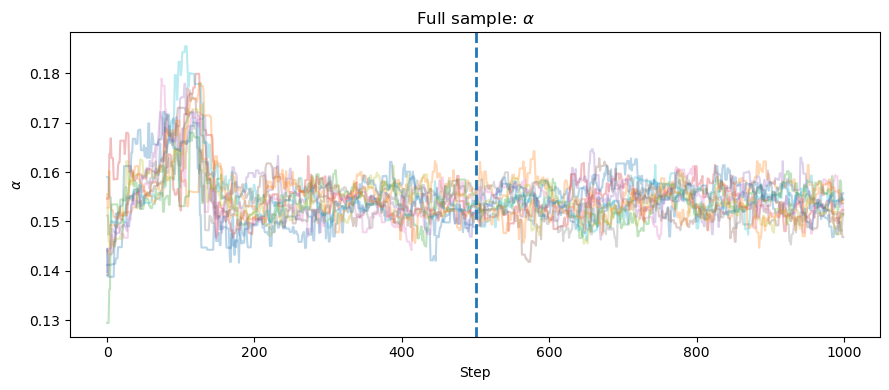

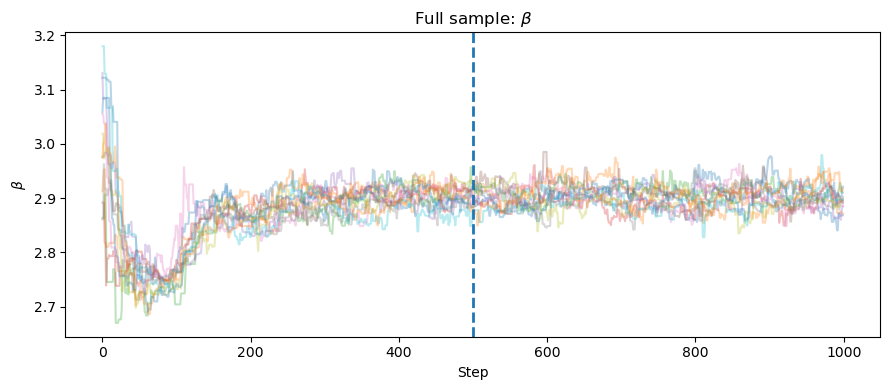

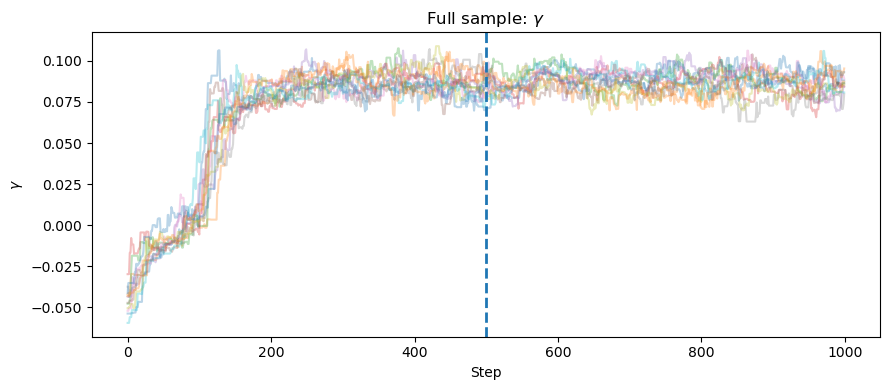

In [40]:
fig = corner.corner(
    clipped_all_samples_4d,
    labels=[
        r"$M_B$",
        r"$\alpha$",
        r"$\beta$",
        r"$\gamma$"
    ],
    levels=(0.683, 0.954),
    color="deeppink",
    plot_datapoints=False,
    plot_density=True,
    fill_contours=False,
    smooth=1.0,
    show_titles=True,
    title_fmt=".3f"
)

fig.suptitle("ZTF corner plot: full sample, 2.5-sigma clipped", fontsize=14, y=1.02)

fig.savefig(
    clipped_4d_dir / "ZTF_clipped_corner_full_sample_4d.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plot_mcmc_diagnostics(
    ztf_sample_clipped_4d,
    clipped_all_samples_4d,
    title="Full sample, 2.5-sigma clipped",
    filename_prefix="ZTF_full_sample",
    clipped=True
)

plot_burnin_diagnostics(
    clipped_all_sampler_4d,
    burnin=burnin,
    title="Full sample",
    filename_prefix="ZTF_full_sample",
    clipped=True
)

# Final Hubble Diagrams

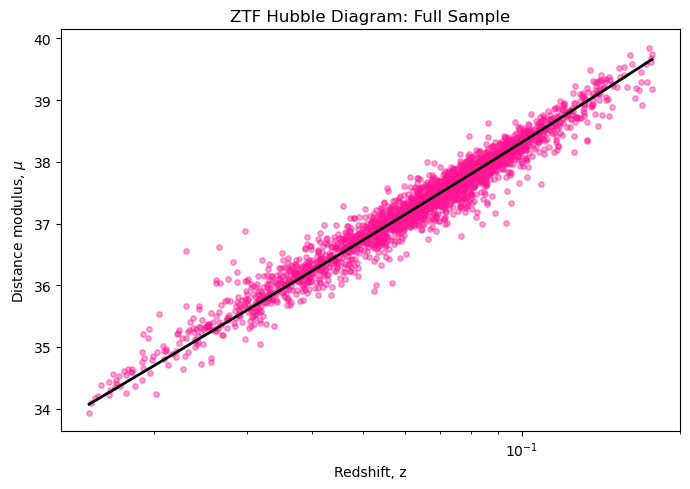

In [41]:
M_B = np.median(all_samples_4d[:, 0])
alpha = np.median(all_samples_4d[:, 1])
beta = np.median(all_samples_4d[:, 2])
gamma = np.median(all_samples_4d[:, 3])

data = ztf_sample_4d[["zHD", "mB", "x1", "c", "HOST_LOGMASS"]].dropna().copy()

HM = (data["HOST_LOGMASS"] >= mass_cut).astype(float)

data["MU"] = data["mB"] - M_B + alpha*data["x1"] - beta*data["c"] + gamma*HM

cosmology = LambdaCDM(H0=H_0, Om0=0.3, Ode0=0.7)

z_plot = np.linspace(data["zHD"].min(), data["zHD"].max(), 500)
mu_plot = cosmology.distmod(z_plot).value

plt.figure(figsize=(7, 5))

plt.scatter(
    data["zHD"],
    data["MU"],
    s=15,
    alpha=0.4,
    color="deeppink"
)

plt.plot(
    z_plot,
    mu_plot,
    color="black",
    linewidth=2
)

plt.xscale("log")
plt.xlabel("Redshift, z")
plt.ylabel(r"Distance modulus, $\mu$")
plt.title("ZTF Hubble Diagram: Full Sample")
plt.tight_layout()
plt.savefig(hubble_dir / "ZTF_hubble_full_sample.png", dpi=300, bbox_inches="tight")
plt.show()

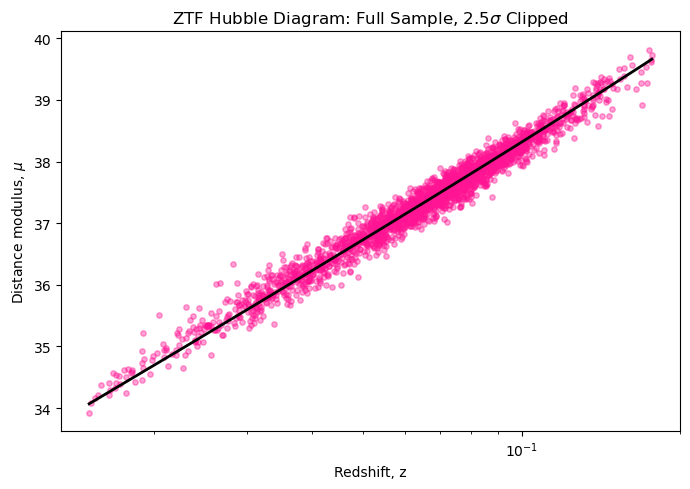

In [42]:
# 2.5-sigma clipped 4D Hubble diagram

M_B = np.median(clipped_all_samples_4d[:, 0])
alpha = np.median(clipped_all_samples_4d[:, 1])
beta = np.median(clipped_all_samples_4d[:, 2])
gamma = np.median(clipped_all_samples_4d[:, 3])

data = ztf_sample_clipped_4d[
    ["zHD", "mB", "x1", "c", "HOST_LOGMASS"]
].dropna().copy()

HM = (data["HOST_LOGMASS"] >= mass_cut).astype(float)

data["MU"] = data["mB"] - M_B + alpha*data["x1"] - beta*data["c"] + gamma*HM

cosmology = LambdaCDM(
    H0=H_0,
    Om0=0.3,
    Ode0=0.7
)

z_plot = np.linspace(
    data["zHD"].min(),
    data["zHD"].max(),
    500
)

mu_plot = cosmology.distmod(z_plot).value

plt.figure(figsize=(7, 5))

plt.scatter(
    data["zHD"],
    data["MU"],
    s=15,
    alpha=0.4,
    color="deeppink"
)

plt.plot(
    z_plot,
    mu_plot,
    color="black",
    linewidth=2
)

plt.xscale("log")
plt.xlabel("Redshift, z")
plt.ylabel(r"Distance modulus, $\mu$")
plt.title(r"ZTF Hubble Diagram: Full Sample, $2.5\sigma$ Clipped")

plt.tight_layout()

plt.savefig(
    hubble_dir / "ZTF_hubble_full_sample_4d_2p5sigma_clipped.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
def plot_hubble_split(
    sample1,
    sample2,
    samples1,
    samples2,
    label1,
    label2,
    color1,
    color2,
    title,
    filename
):
    M_B_1 = np.median(samples1[:, 0])
    alpha_1 = np.median(samples1[:, 1])
    beta_1 = np.median(samples1[:, 2])
    gamma_1 = np.median(samples1[:, 3]) if samples1.shape[1] > 3 else 0.0

    M_B_2 = np.median(samples2[:, 0])
    alpha_2 = np.median(samples2[:, 1])
    beta_2 = np.median(samples2[:, 2])
    gamma_2 = np.median(samples2[:, 3]) if samples2.shape[1] > 3 else 0.0

    data1 = sample1[["zHD", "mB", "x1", "c", "HOST_LOGMASS"]].dropna().copy()
    data2 = sample2[["zHD", "mB", "x1", "c", "HOST_LOGMASS"]].dropna().copy()

    HM1 = (data1["HOST_LOGMASS"] >= mass_cut).astype(float)
    HM2 = (data2["HOST_LOGMASS"] >= mass_cut).astype(float)

    data1["MU"] = data1["mB"] - M_B_1 + alpha_1*data1["x1"] - beta_1*data1["c"] + gamma_1*HM1
    data2["MU"] = data2["mB"] - M_B_2 + alpha_2*data2["x1"] - beta_2*data2["c"] + gamma_2*HM2

    cosmology1 = LambdaCDM(H0=H_0, Om0=0.3, Ode0=0.7)
    cosmology2 = LambdaCDM(H0=H_0, Om0=0.3, Ode0=0.7)

    z_min = min(data1["zHD"].min(), data2["zHD"].min())
    z_max = max(data1["zHD"].max(), data2["zHD"].max())
    z_plot = np.linspace(z_min, z_max, 500)

    plt.figure(figsize=(7, 5))

    plt.scatter(data1["zHD"], data1["MU"], s=15, alpha=0.4, color=color1, label=label1)
    plt.scatter(data2["zHD"], data2["MU"], s=15, alpha=0.4, color=color2, label=label2)

    plt.plot(z_plot, cosmology1.distmod(z_plot).value, color=color1, linewidth=2)
    plt.plot(z_plot, cosmology2.distmod(z_plot).value, color=color2, linewidth=2)

    plt.xscale("log")
    plt.xlabel("Redshift, z")
    plt.ylabel(r"Distance modulus, $\mu$")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

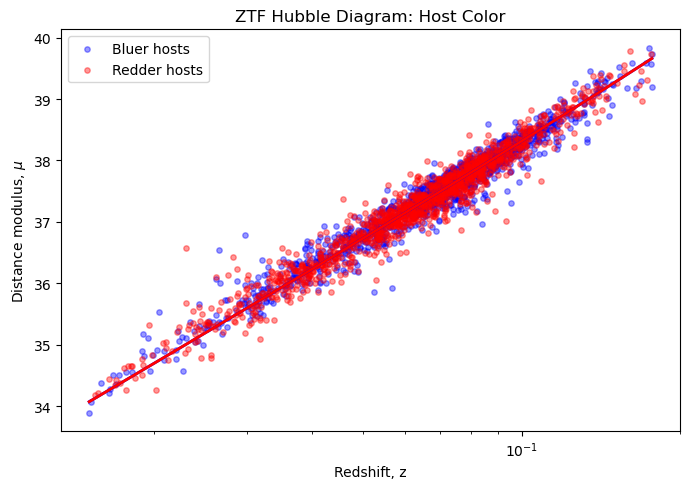

In [44]:
plot_hubble_split(
    blue_df_4d,
    red_df_4d,
    blue_samples_4d,
    red_samples_4d,
    "Bluer hosts",
    "Redder hosts",
    "blue",
    "red",
    "ZTF Hubble Diagram: Host Color",
    hubble_dir / "ZTF_hubble_host_color.png"
)

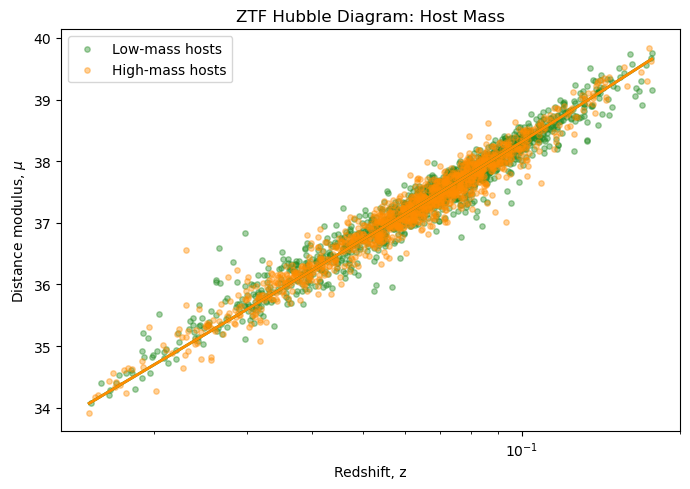

In [45]:
plot_hubble_split(
    low_mass_df_3d,
    high_mass_df_3d,
    low_mass_samples_3d,
    high_mass_samples_3d,
    "Low-mass hosts",
    "High-mass hosts",
    "forestgreen",
    "darkorange",
    "ZTF Hubble Diagram: Host Mass",
    hubble_dir / "ZTF_hubble_host_mass.png"
)

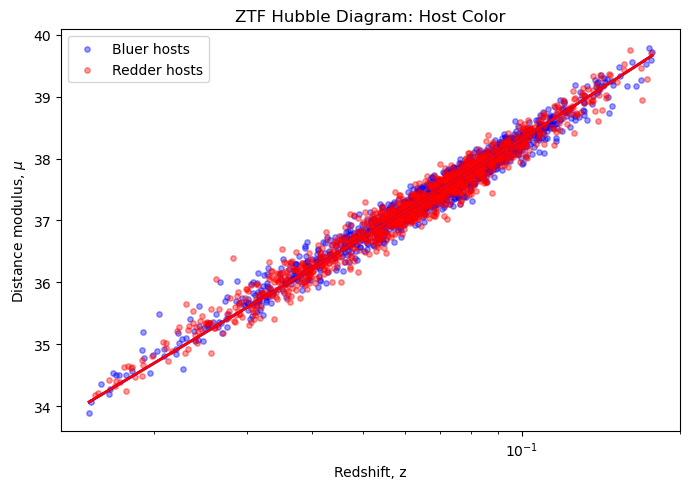

In [46]:
plot_hubble_split(
    clipped_blue_df_4d,
    clipped_red_df_4d,
    clipped_blue_samples_4d,
    clipped_red_samples_4d,
    "Bluer hosts",
    "Redder hosts",
    "blue",
    "red",
    "ZTF Hubble Diagram: Host Color",
    hubble_dir / "ZTF_clipped_hubble_host_color.png"
)


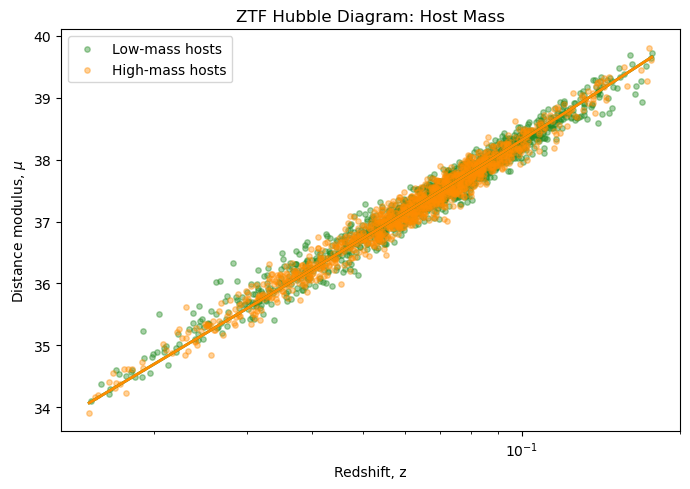

In [47]:
plot_hubble_split(
    clipped_low_mass_df_3d,
    clipped_high_mass_df_3d,
    clipped_low_mass_samples_3d,
    clipped_high_mass_samples_3d,
    "Low-mass hosts",
    "High-mass hosts",
    "forestgreen",
    "darkorange",
    "ZTF Hubble Diagram: Host Mass",
    hubble_dir / "ZTF_clipped_hubble_host_mass.png"
)